## Section 1 - Environment Setup and Dependency Installation

In [2]:
!pip install -q unsloth immutables optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Menginstal ulang library mergekit langsung dari repository GitHub resmi arcee-ai
# (bukan dari PyPI), dengan --force-reinstall untuk memastikan versi terbaru
# terpasang meski sudah ada versi lain sebelumnya, dan --no-deps untuk menghindari
# instalasi ulang dependency yang mungkin sudah tersedia (mencegah konflik versi
# dengan library lain seperti torch atau transformers yang sudah terpasang).
!pip install -U --force-reinstall --no-deps "git+https://github.com/arcee-ai/mergekit.git"

  Cloning https://github.com/arcee-ai/mergekit.git to /tmp/pip-req-build-8ksu181_
  Running command git clone --filter=blob:none --quiet https://github.com/arcee-ai/mergekit.git /tmp/pip-req-build-8ksu181_
  Resolved https://github.com/arcee-ai/mergekit.git to commit a6e402884ba9bc30da7f23e8304a35f19485de95
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mergekit: filename=mergekit-0.1.4-py3-none-any.whl size=205217 sha256=bb5895443f83a7a55ed903f1f1596acd66423960b88140ed659a87cd4c476d56
  Stored in directory: /tmp/pip-ephem-wheel-cache-76lfwr2s/wheels/e0/ff/07/67fd02dd5a354d3552b9b78bb229e8a25bea07d0028f356106
Successfully built mergekit


In [ ]:
!pip install "pydantic<2.10" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.16.0
    Uninstalling typing_extensions-4.16.0:
      Successfully uninstalled typing_extensions-4.16.0
  Attempting uninstall: annotated-types
    Found existing installation: annotated-types 0.7.0
    Uninstalling annotated-types-0.7.0:
      Successfully uninstalled annotated-types-0.7.0
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.46.4
    Uninstalling pydantic_core-2.46.4:
      Successfully uninstalled pydantic_core-2.46.4
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.13.4
    Uninstalling pydantic-2.13

## Section 2 — Library Imports, Experimental Reproducibility, and Configuration

In [1]:
import unsloth

import gc
import glob
import json
import os
import random
import re
import shutil
import warnings
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
import transformers
from safetensors.torch import load_file
from sklearn.model_selection import train_test_split
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
from unsloth import FastLanguageModel

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath

import optuna
import yaml
from tqdm.auto import tqdm

from google.colab import drive

# from mergekit.config import MergeConfiguration
# from mergekit.merge import MergeOptions, run_merge

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
drive.mount("/content/drive")

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
optuna.logging.set_verbosity(optuna.logging.WARNING)

Mounted at /content/drive


### Reproducibility Seed Setting

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Main Folder Setting

In [5]:
# ID model Hugging Face Hub untuk kedua model baseline yang akan digunakan
# sebagai basis proses SLERP merging: model math-specialized dan model general.
MODEL_MATH = "Qwen/Qwen2.5-Math-1.5B-Instruct"
MODEL_GENERAL = "Qwen/Qwen2.5-1.5B-Instruct"

# Dataset
# Path ke file dataset test GSM8K (full size, versi V3) yang tersimpan di
# Google Drive, digunakan sebagai basis evaluasi baik untuk baseline maupun
# untuk hasil model merging.
DATASET_PATH = "/content/drive/MyDrive/Dataset Skripsi/dataset/test/Full Size Test Set - V3/GSM8K Test Set.json"

# Path ke dataset untuk pencarian nilai t terbaik dengan Optuna
OPTUNA_SAMPLE_MODEL_MERGING_PATH = "/content/drive/MyDrive/Dataset Skripsi/dataset/slerp/val_tsearch_pool.xlsx"

# Output Path
# Direktori root untuk seluruh output eksperimen model merging tahap ini
# (dual prompt, full size dataset), tempat semua subdirektori di bawah
# (sample, config, evaluation, charts, hasil merge final) akan disimpan.
ROOT_OUTPUT_DIR = (
    "/content/drive/MyDrive/Dataset Skripsi/"
    "Result Model Merging Dual Prompt Full Size"
)

# Direktori untuk menyimpan sampel hasil pencarian hyperparameter SLERP
# menggunakan Optuna (misal koefisien interpolasi yang dicoba per trial).
SAMPLE_DIR = os.path.join(
    ROOT_OUTPUT_DIR,
    "optuna_sample"
)

# Direktori untuk menyimpan file konfigurasi YAML mergekit yang dihasilkan
# untuk setiap kombinasi/trial merging yang dicoba.
CONFIG_DIR = os.path.join(
    ROOT_OUTPUT_DIR,
    "configs"
)

# Direktori untuk menyimpan seluruh hasil evaluasi (JSONL, XLSX, CSV) dari
# model-model yang dievaluasi selama proses merging.
EVAL_DIR = os.path.join(
    ROOT_OUTPUT_DIR,
    "evaluation"
)

# Path file CSV yang mencatat hasil seluruh trial pencarian Optuna, dengan
# suffix nama yang menandakan trial ini menggunakan 20% sampel dataset dan
# hanya bahasa Indonesia (untuk mempercepat pencarian sebelum evaluasi final
# pada dataset penuh dan kedua bahasa).
TRIAL_RESULTS_PATH = os.path.join(
    EVAL_DIR,
    "slerp_optuna_trials_20pct_indonesian_only.csv",
)

# Direktori untuk menyimpan seluruh chart/visualisasi hasil eksperimen ini.
CHARTS_DIR = os.path.join(
    ROOT_OUTPUT_DIR,
    "charts"
)

# Direktori untuk menyimpan model hasil SLERP merging final (setelah koefisien
# terbaik ditemukan dari pencarian Optuna), yang akan dievaluasi secara penuh.
FINAL_MERGE_DIR = os.path.join(
    ROOT_OUTPUT_DIR,
    "final_slerp_mergekit"
)

# Path ke file ringkasan baseline (hasil evaluasi model general dan math
# sebelum merging), dipakai sebagai referensi pembanding terhadap performa
# model hasil merging nantinya.
BASELINE_SUMMARY_PATH = os.path.join(
    ROOT_OUTPUT_DIR,
    "baseline_summary_v2.csv"
)

# Direktori sementara di local disk Colab (bukan Google Drive) untuk menyimpan
# model-model hasil merge selama proses trial Optuna, karena menulis banyak
# checkpoint model besar berulang kali ke Google Drive akan jauh lebih lambat
# dan berisiko terkena limit I/O dibanding menyimpan di disk lokal sesi Colab.
TRIAL_MERGE_DIR = "/content/slerp_merge_trials"

# Membuat seluruh direktori di atas jika belum ada, agar seluruh path output
# eksperimen (kecuali FINAL_MERGE_DIR dan BASELINE_SUMMARY_PATH yang tidak
# diiterasi di sini) sudah siap sebelum eksperimen merging dan evaluasi berjalan.
for directory in [
    ROOT_OUTPUT_DIR,
    SAMPLE_DIR,
    CONFIG_DIR,
    EVAL_DIR,
    CHARTS_DIR,
    TRIAL_MERGE_DIR,
]:
    os.makedirs(directory, exist_ok=True)

### Inference and Chart Static Variable

In [6]:
STRATA = ["L1", "L2", "L3"]

ENCOLOR = "#4A90D9"
IDCOLOR = "#E74C3C"
GENERAL_COLOR = "#6C757D"
MATH_COLOR = "#4A90D9"
SLERP_COLOR = "#E74C3C"

MAX_SEQ_LENGTH = 2048
LOAD_IN_4BIT = False

GENERATION_CONFIG = {
    "max_new_tokens": 1024,
    "do_sample": False,
    "use_cache": True,
}

### Optuna (Best Alpha Searching) Static Variable

In [7]:
# Batas bawah dan batas atas rentang pencarian nilai alpha (koefisien
# interpolasi SLERP) yang akan dieksplorasi oleh Optuna. Rentang ini sengaja
# dibuat sempit (0.075-0.09) daripada rentang penuh SLERP (0.0-1.0)
# berdasarkan hasil eksplorasi awal/manual sudah menunjukkan area sekitar nilai ini
# sebagai kandidat optimal, sehingga pencarian difokuskan pada area tersebut
# untuk menghemat waktu dan resource komputasi.
ALPHA_MIN = 0.075
ALPHA_MAX = 0.09

# Jumlah total trial yang akan dijalankan Optuna untuk mencari nilai alpha
# terbaik dalam rentang [ALPHA_MIN, ALPHA_MAX], di mana setiap trial berarti
# satu proses merging model dengan alpha berbeda, diikuti evaluasi pada
# sampel dataset untuk mengukur akurasinya.
N_OPTUNA_TRIALS = 20

# Jumlah trial awal yang dijalankan secara acak (random sampling) sebelum
# Optuna mulai menggunakan strategi sampling yang lebih terarah (misal
# Bayesian optimization via TPE Sampler), untuk membangun eksplorasi awal
# ruang pencarian sebelum eksploitasi area yang menjanjikan.
N_STARTUP_TRIALS = 5

## Section 3 - Utils & Data Preprocessing

In [8]:
def normalize_number(text):
    """Menormalisasi string jawaban numerik agar bisa dibandingkan secara exact-match pada GSM8K.

    Fungsi ini membersihkan simbol mata uang, satuan kata dalam Bahasa Indonesia,
    dan tanda baca pemisah ribuan, lalu mengonversi hasilnya menjadi representasi
    desimal ternormalisasi (tanpa trailing zero) agar "10.0" dan "10" dianggap sama.

    Args:
        text: Nilai mentah yang akan dinormalisasi. Bisa berupa str, angka, atau None.

    Returns:
        String angka yang sudah dinormalisasi (misal "10.5"), atau string huruf kecil
        dari teks asli jika teks tidak bisa dikonversi ke angka. Mengembalikan None
        jika input adalah None.
    """
    if text is None:
        return None

    text = str(text).strip()

    text = text.replace("$", "")
    text = text.replace("Rp.", "")
    text = text.replace("Rp", "")
    text = text.replace("\,", "")
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.strip().rstrip(".")

    # Pattern: \b...\b memastikan hanya kata utuh yang cocok, (?i) membuat pencarian
    # tidak case-sensitive, dan grup (orang|buah|...) mendaftar satuan yang akan dihapus.
    text = re.sub(r"(?i)\b(orang|buah|kali|rupiah|unit|hari|jam|menit)\b", "", text)
    text = text.strip()

    # Pattern: -?\d+/\d+ mencocokkan pecahan opsional negatif dengan format "pembilang/penyebut".
    if re.fullmatch(r"-?\d+/\d+", text):
        numerator, denominator = text.split("/")
        if denominator != "0":
            value = Decimal(numerator) / Decimal(denominator)
            return format(value.normalize(), "f")

    try:
        value = Decimal(text)
        return format(value.normalize(), "f")
    except (InvalidOperation, ValueError):
        return text.lower()


def extract_answer(text):
    """Mengekstrak jawaban akhir dari teks keluaran model berdasarkan urutan prioritas pattern.

    Prioritas ekstraksi:
    1. Pola \\boxed{...} (format umum pada output reasoning matematika).
    2. Pola "#### ..." (format marker jawaban khas dataset GSM8K).
    3. Angka terakhir yang muncul di teks sebagai fallback jika kedua pola di atas tidak ditemukan.

    Args:
        text: Teks keluaran model yang akan diekstrak jawabannya. Bisa berupa str atau None.

    Returns:
        Tuple (jawaban, metode) di mana jawaban adalah string hasil ekstraksi (atau None
        jika tidak ditemukan) dan metode adalah salah satu dari "boxed", "gsm8k_marker",
        "last_number_fallback", "missing", atau "not_found".
    """
    if text is None:
        return None, "missing"

    text = str(text).strip()

    patterns = [
        # Pattern: \\boxed\{([^{}]+)\} menangkap isi di dalam \boxed{...},
        # dengan [^{}]+ memastikan tidak melintasi kurung kurawal lain di dalamnya.
        (r"\\boxed\{([^{}]+)\}", "boxed"),
        # Pattern: (?im) mengaktifkan mode multiline + case-insensitive, ^\s*####\s*
        # mencocokkan baris yang diawali tanda "####" (dengan spasi opsional),
        # dan ([^\n]+) menangkap sisa teks di baris tersebut sebagai jawaban.
        (r"(?im)^\s*####\s*([^\n]+)", "gsm8k_marker"),
    ]

    for pattern, method in patterns:
        matches = re.findall(pattern, text)

        # Hanya menerima kecocokan yang tidak kosong dan mengandung setidaknya satu digit,
        # untuk menghindari hasil tangkapan yang berupa teks non-numerik.
        valid_matches = [m.strip() for m in matches if m.strip() and re.search(r"\d", m)]
        if valid_matches:
            return valid_matches[-1], method

    # Pattern: -?\d+(?:[.,]\d+)?(?:/\d+)? mencocokkan angka opsional negatif,
    # dengan bagian desimal opsional (dipisah titik atau koma) dan bagian pecahan opsional.
    numbers = re.findall(r"-?\d+(?:[.,]\d+)?(?:/\d+)?", text)
    if numbers:
        return numbers[-1].strip(), "last_number_fallback"

    return None, "not_found"


def is_correct(raw_output, ground_truth):
    """Mengevaluasi apakah jawaban model benar dengan membandingkan hasil normalisasi.

    Fungsi ini mengekstrak jawaban dari output mentah model, menormalisasi jawaban
    tersebut beserta ground truth, lalu membandingkannya secara exact-match.

    Args:
        raw_output: Teks keluaran mentah dari model yang akan dievaluasi.
        ground_truth: Jawaban benar (referensi) untuk dibandingkan.

    Returns:
        Dictionary berisi prediction (jawaban hasil ekstraksi), normalized_prediction,
        normalized_ground_truth, extraction_method (metode ekstraksi yang berhasil),
        dan correct (boolean status kebenaran jawaban).
    """
    prediction, extraction_method = extract_answer(raw_output)

    normalized_prediction = normalize_number(prediction)
    normalized_ground_truth = normalize_number(ground_truth)

    correct = (
        normalized_prediction is not None
        and normalized_prediction == normalized_ground_truth
    )

    return {
        "prediction": prediction,
        "normalized_prediction": normalized_prediction,
        "normalized_ground_truth": normalized_ground_truth,
        "extraction_method": extraction_method,
        "correct": correct,
    }


def clear_vram(model=None, tokenizer=None):
    """Membersihkan objek model dan tokenizer dari memori serta mengosongkan cache VRAM GPU.

    Fungsi ini berguna untuk mencegah kebocoran memori (memory leak) saat melakukan
    eksperimen berulang dengan banyak model pada satu sesi Google Colab atau notebook.

    Args:
        model: Objek model yang akan dihapus dari memori. Opsional, default None.
        tokenizer: Objek tokenizer yang akan dihapus dari memori. Opsional, default None.

    Returns:
        None.
    """
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer

    # Memaksa garbage collector Python untuk membebaskan objek yang sudah di-delete.
    gc.collect()

    if torch.cuda.is_available():
        # Mengosongkan cache alokasi memori CUDA yang sudah tidak dipakai agar VRAM
        # yang telah dibebaskan benar-benar bisa digunakan kembali oleh proses lain.
        torch.cuda.empty_cache()

## Section 4 - System Prompts, Dataset Loading & Inference Engine

### Prompts

In [ ]:
SYSTEM_PROMPT_EN = r"""
You are a mathematical reasoning assistant.

Solve the problem carefully, step by step.
On the final line, write only the final numerical answer in this format:
\boxed{value}
"""

SYSTEM_PROMPT_ID = r"""
Anda adalah asisten penalaran matematika.

Selesaikan soal dengan cermat secara bertahap.
Pada baris terakhir, tuliskan hanya jawaban numerik akhir dengan format:
\boxed{nilai}
"""

### Dataset Loading

In [10]:
# Membuka file dataset dan memuat isinya sebagai struktur data Python (list of dict).
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    raw_dataset = json.load(f)

# Mendefinisikan field wajib yang harus ada pada setiap entri dataset, mencakup
# soal versi Inggris, versi terjemahan, jawaban, dan label strata/tingkat kesulitan.
required_fields = {"question", "translated_question", "answer", "stratum"}

# Memvalidasi setiap entri dataset satu per satu untuk memastikan tidak ada field
# yang hilang, sekaligus melacak indeks entri yang bermasalah untuk debugging.
for idx, item in enumerate(raw_dataset):
    missing = required_fields - set(item.keys())
    if missing:
        raise ValueError(f"Data indeks {idx} tidak memiliki field: {missing}")

# Mengonversi list of dict menjadi DataFrame agar mudah dimanipulasi secara kolumnar.
df_test = pd.DataFrame(raw_dataset)

# Memastikan setiap kolom teks bertipe string dan membersihkan whitespace di awal/akhir,
# untuk mencegah kegagalan pencocokan akibat spasi tersembunyi dari proses translasi/loading.
df_test["question"] = df_test["question"].astype(str).str.strip()
df_test["translated_question"] = df_test["translated_question"].astype(str).str.strip()
df_test["answer"] = df_test["answer"].astype(str).str.strip()
df_test["stratum"] = df_test["stratum"].astype(str).str.strip()

# Memvalidasi bahwa seluruh label stratum yang muncul di dataset merupakan bagian
# dari daftar strata yang telah ditentukan (STRATA), untuk mencegah typo atau label asing.
if not set(df_test["stratum"].unique()).issubset(set(STRATA)):
    raise ValueError(
        f"Strata tidak valid: {sorted(df_test['stratum'].unique())}"
    )

# Mengekstrak masing-masing kolom menjadi list Python terpisah agar mudah diiterasi
# atau dipasangkan (misal saat looping untuk inference per soal).
full_q_en = df_test["question"].tolist()
full_q_id = df_test["translated_question"].tolist()
full_answers = df_test["answer"].tolist()
full_strata = df_test["stratum"].tolist()

### Sample For Optuna

In [12]:
# Memuat sheet "Final Pool" sebagai sampel evaluasi tetap untuk pencarian alpha
# menggunakan Optuna. Sampel ini tidak diambil ulang secara acak pada setiap
# run, sehingga seluruh trial Optuna dievaluasi pada subset soal yang identik
# dan skor antar-trial dapat dibandingkan secara adil.
df_optuna_sample = pd.read_excel(
    OPTUNA_SAMPLE_MODEL_MERGING_PATH,
    sheet_name="Final Pool",
)

# Mereset index DataFrame menjadi urutan 0 sampai n-1 tanpa mengubah isi atau
# urutan sampel, agar index konsisten setelah data dimuat dari sheet Excel.
df_optuna_sample = df_optuna_sample.reset_index(drop=True)

### Model Loader

In [ ]:
def load_model_for_inference(model_name):
    """Memuat model dan tokenizer dari Hugging Face/lokal dalam mode siap-inference.

    Fungsi ini menggunakan Unsloth's FastLanguageModel untuk memuat model dengan
    opsi kuantisasi 4-bit, mengaktifkan mode inference (bukan training), dan
    memastikan tokenizer memiliki pad_token yang valid sebelum digunakan.

    Args:
        model_name: Nama atau path model yang akan dimuat, bisa berupa ID model
            Hugging Face Hub atau path lokal ke checkpoint model.

    Returns:
        Tuple (model, tokenizer) yang siap digunakan untuk proses inference.
    """
    # Memuat model dan tokenizer dengan konfigurasi panjang sequence maksimum dan
    # kuantisasi 4-bit (jika LOAD_IN_4BIT True) untuk menghemat penggunaan VRAM.
    # dtype=None membiarkan Unsloth memilih tipe data optimal secara otomatis.
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=LOAD_IN_4BIT,
    )

    # Mengoptimalkan model untuk mode inference (menonaktifkan komponen yang hanya
    # relevan saat training, seperti gradient checkpointing), sehingga generasi
    # teks berjalan lebih cepat.
    FastLanguageModel.for_inference(model)

    # Beberapa model tidak memiliki pad_token bawaan, sehingga perlu di-fallback
    # ke eos_token agar proses padding saat batching tidak menyebabkan error.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

### Engine

In [ ]:
def run_inference(
    model,
    tokenizer,
    questions,
    system_prompt,
    batch_size=16,
    max_new_tokens=1024,
    desc="Inference",
):
    """Menjalankan inference batch dengan greedy decoding untuk daftar pertanyaan.

    Fungsi ini memproses pertanyaan secara batch menggunakan chat template,
    melakukan generasi teks dengan greedy decoding (deterministik, tanpa sampling),
    lalu memotong output agar hanya menyisakan token hasil generasi (tanpa prompt).
    Padding menggunakan left padding karena posisi awal sequence yang bervariasi
    panjangnya harus disamakan di sisi kiri agar pemotongan berdasarkan panjang
    prompt tetap valid untuk seluruh item dalam batch.

    Args:
        model: Model bahasa yang sudah dimuat dan siap untuk inference.
        tokenizer: Tokenizer yang berpasangan dengan model.
        questions: List string pertanyaan yang akan diproses.
        system_prompt: Instruksi sistem yang disisipkan ke setiap chat template.
        batch_size: Jumlah pertanyaan yang diproses dalam satu batch. Default 16.
        max_new_tokens: Batas maksimum token baru yang digenerate per pertanyaan.
            Default 1024.
        desc: Label deskripsi yang ditampilkan pada progress bar tqdm. Default "Inference".

    Returns:
        List string berisi jawaban hasil generasi model untuk setiap pertanyaan,
        dengan urutan yang sama seperti input questions.
    """
    # Mengatur model ke mode evaluasi agar layer seperti dropout tidak aktif,
    # dan mengatur padding di sisi kiri karena decoder-only model men-generate
    # token baru dari posisi paling kanan sequence.
    model.eval()
    tokenizer.padding_side = "left"

    # Fallback pad_token ke eos_token jika tokenizer belum memilikinya, agar
    # proses padding saat batching tidak menyebabkan error.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    all_outputs = []

    # Memproses pertanyaan per batch (bukan satu-satu) untuk memanfaatkan
    # paralelisme GPU dan mempercepat inference secara keseluruhan.
    for start_idx in tqdm(
        range(0, len(questions), batch_size),
        desc=desc,
    ):
        batch_questions = questions[start_idx : start_idx + batch_size]

        # Membungkus setiap pertanyaan ke dalam format chat (system + user),
        # lalu mengonversinya menjadi string prompt mentah tanpa tokenisasi
        # (tokenize=False), dengan add_generation_prompt=True agar template
        # menyertakan penanda yang memberi sinyal model untuk mulai merespons.
        batch_texts = [
            tokenizer.apply_chat_template(
                [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": question.strip()},
                ],
                tokenize=False,
                add_generation_prompt=True,
            )
            for question in batch_questions
        ]

        # Melakukan tokenisasi batch dengan padding otomatis dan truncation
        # jika melebihi MAX_SEQ_LENGTH, lalu memindahkan tensor ke device
        # yang sama dengan model (GPU/CPU).
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
        ).to(model.device)

        # Menjalankan generasi teks tanpa melacak gradient (inference_mode)
        # untuk menghemat memori dan mempercepat komputasi. do_sample=False
        # membuat decoding bersifat greedy dan deterministik (bukan acak).
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True,
            )

        # Karena left padding, seluruh prompt dalam batch memiliki panjang
        # ter-padding yang sama, sehingga token hasil generasi bisa dipotong
        # secara konsisten mulai dari indeks prompt_length untuk semua item.
        prompt_length = inputs.input_ids.shape[1]
        generated_tokens = outputs[:, prompt_length:]

        # Mendekode token hasil generasi kembali menjadi teks, membuang
        # token spesial (seperti eos_token) agar output bersih.
        decoded_outputs = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True,
        )

        all_outputs.extend(output.strip() for output in decoded_outputs)

        # Menghapus tensor besar dari memori secara eksplisit setiap batch
        # untuk mencegah akumulasi penggunaan VRAM selama loop berjalan.
        del inputs, outputs, generated_tokens

    return all_outputs

## Section 5 - Evaluation Pipeline

In [ ]:
def evaluate_and_save(
    questions,
    raw_outputs,
    ground_truths,
    strata_list,
    output_prefix,
    language,
    model_name,
    prompt_name,
):
    """Mengevaluasi hasil inference model, menyimpan detail per soal, dan meringkas metrik akurasi.

    Fungsi ini membandingkan setiap output mentah model dengan ground truth menggunakan
    is_correct, menyusun hasilnya menjadi DataFrame, menyimpannya ke tiga format file
    (JSONL, XLSX, CSV), lalu menghitung dan mencetak akurasi keseluruhan, akurasi per
    stratum, serta distribusi metode ekstraksi jawaban yang digunakan.

    Args:
        questions: List pertanyaan yang dievaluasi.
        raw_outputs: List output mentah dari model untuk setiap pertanyaan.
        ground_truths: List jawaban benar (referensi) untuk setiap pertanyaan.
        strata_list: List label stratum/tingkat kesulitan untuk setiap pertanyaan.
        output_prefix: Prefix path file untuk menyimpan hasil (tanpa ekstensi).
        language: Label bahasa soal yang dievaluasi (misal "en" atau "id").
        model_name: Nama model yang dievaluasi, dicatat sebagai metadata pada setiap baris.
        prompt_name: Nama/varian prompt yang digunakan, dicatat sebagai metadata.

    Returns:
        Dictionary berisi accuracy (float akurasi keseluruhan), per_stratum (dict akurasi
        per stratum), extraction_stats (dict persentase metode ekstraksi), dan dataframe
        (DataFrame lengkap hasil evaluasi per soal).

    Raises:
        ValueError: Jika panjang questions, raw_outputs, ground_truths, dan strata_list
            tidak sama.
    """
    # Validasi awal untuk memastikan keempat list saling berpasangan (soal, output,
    # jawaban, stratum) sebelum di-zip, mencegah misalignment data secara diam-diam.
    if not (
        len(questions)
        == len(raw_outputs)
        == len(ground_truths)
        == len(strata_list)
    ):
        raise ValueError("Panjang questions, outputs, answers, dan strata harus sama.")

    records = []

    # Mengevaluasi setiap soal satu per satu menggunakan is_correct, lalu menyusun
    # hasilnya menjadi satu record lengkap berisi metadata (model, bahasa, prompt)
    # dan detail evaluasi (prediksi, normalisasi, metode ekstraksi, status benar/salah).
    for question, raw_output, answer, stratum in zip(
        questions,
        raw_outputs,
        ground_truths,
        strata_list,
    ):
        result = is_correct(raw_output, answer)

        records.append(
            {
                "model": model_name,
                "language": language,
                "prompt_name": prompt_name,
                "question": question,
                "raw_output": raw_output,
                "extracted_answer": result["prediction"],
                "normalized_prediction": result["normalized_prediction"],
                "ground_truth": answer,
                "normalized_ground_truth": result["normalized_ground_truth"],
                "extraction_method": result["extraction_method"],
                "stratum": stratum,
                "correct": result["correct"],
            }
        )

    df_results = pd.DataFrame(records)

    output_jsonl = f"{output_prefix}.jsonl"
    output_xlsx = f"{output_prefix}.xlsx"
    output_csv = f"{output_prefix}.csv"

    # Menyimpan hasil ke tiga format berbeda: JSONL untuk pemrosesan lanjutan/pipeline,
    # XLSX untuk inspeksi manual, dan CSV (dengan encoding utf-8-sig agar kompatibel
    # dibuka di Excel tanpa masalah karakter non-ASCII seperti teks Bahasa Indonesia).
    df_results.to_json(
        output_jsonl,
        orient="records",
        lines=True,
        force_ascii=False,
    )
    df_results.to_excel(output_xlsx, index=False)
    df_results.to_csv(output_csv, index=False, encoding="utf-8-sig")

    # Menghitung akurasi keseluruhan sebagai rata-rata kolom boolean "correct".
    accuracy = df_results["correct"].mean()

    # Menghitung akurasi per stratum, dengan reindex ke STRATA agar stratum yang
    # tidak muncul sama sekali pada batch ini tetap tercatat dengan nilai 0.0
    # (bukan hilang dari hasil), menjaga konsistensi struktur output antar run.
    per_stratum = (
        df_results.groupby("stratum")["correct"]
        .mean()
        .reindex(STRATA, fill_value=0.0)
        .to_dict()
    )

    # Menghitung persentase kemunculan setiap metode ekstraksi (boxed, gsm8k_marker,
    # last_number_fallback, dst) untuk melihat seberapa sering model menghasilkan
    # format jawaban yang diharapkan versus butuh fallback.
    extraction_stats = (
        df_results["extraction_method"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    print(f"\nModel        : {model_name}")
    print(f"Bahasa         : {language}")
    print(f"Prompt         : {prompt_name}")
    print(f"Akurasi        : {accuracy * 100:.2f}%")
    print("Akurasi strata :")
    for stratum, score in per_stratum.items():
        print(f"  {stratum}: {score * 100:.2f}%")

    print("Metode ekstraksi jawaban (%):")
    print(extraction_stats)

    return {
        "accuracy": accuracy,
        "per_stratum": per_stratum,
        "extraction_stats": extraction_stats,
        "dataframe": df_results,
    }

### Evaluator Cepat untuk Optuna

In [ ]:
def evaluate_accuracy_only(
    raw_outputs,
    ground_truths,
):
    """Menghitung akurasi cepat tanpa menyimpan detail per soal atau file output.

    Fungsi ini adalah versi ringkas dari evaluate_and_save yang hanya mengembalikan
    skor akurasi tunggal, tanpa I/O ke disk (JSONL/XLSX/CSV) maupun breakdown per
    stratum/metode ekstraksi. Cocok digunakan pada proses pencarian hyperparameter
    (misal trial Optuna untuk koefisien SLERP) yang membutuhkan evaluasi cepat
    berulang kali tanpa overhead penulisan file di setiap trial.

    Args:
        raw_outputs: List output mentah dari model untuk setiap pertanyaan.
        ground_truths: List jawaban benar (referensi) untuk setiap pertanyaan.

    Returns:
        Float akurasi keseluruhan (proporsi jawaban benar, skala 0.0-1.0).

    Raises:
        ValueError: Jika panjang raw_outputs dan ground_truths tidak sama.
    """
    # Validasi awal untuk memastikan setiap output punya pasangan ground truth,
    # mencegah misalignment data sebelum proses zip dan evaluasi berjalan.
    if len(raw_outputs) != len(ground_truths):
        raise ValueError(
            "Jumlah output dan ground truth tidak sama."
        )

    correct_flags = []

    # Mengevaluasi setiap pasangan output-ground truth menggunakan is_correct,
    # tapi hanya menyimpan status benar/salah (boolean), tanpa detail ekstraksi
    # atau normalisasi seperti pada evaluate_and_save, demi efisiensi memori
    # dan kecepatan saat dipanggil berulang kali dalam loop pencarian.
    for raw_output, ground_truth in zip(
        raw_outputs,
        ground_truths,
    ):
        result = is_correct(raw_output, ground_truth)
        correct_flags.append(result["correct"])

    return float(np.mean(correct_flags))

### Load Full Size/Original Model

In [ ]:
print("Memuat model Math dalam BF16...")
# Memuat model math secara penuh (bukan versi 4-bit Unsloth) dengan precision
# bfloat16, karena mergekit umumnya bekerja pada state_dict mentah dan butuh
# bobot floating point utuh (bukan hasil kuantisasi) agar operasi interpolasi
# SLERP menghasilkan bobot merge yang valid secara numerik.
source_math_model = AutoModelForCausalLM.from_pretrained(
    MODEL_MATH,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

print("Memuat model General dalam BF16...")
# Memuat model general dengan konfigurasi yang sama seperti model math, agar
# kedua model source berada pada precision dan format yang identik sebelum
# proses merging, mencegah bias numerik dari perbedaan precision.
source_general_model = AutoModelForCausalLM.from_pretrained(
    MODEL_GENERAL,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

print("Memuat template model Math...")
# Memuat instance model math kedua yang berfungsi sebagai "template" struktur
# (arsitektur dan konfigurasi) untuk menampung hasil bobot merge nantinya,
# terpisah dari source_math_model yang state_dict-nya akan dipakai sebagai
# salah satu sumber interpolasi.
merge_template_model = AutoModelForCausalLM.from_pretrained(
    MODEL_MATH,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

# Memuat tokenizer dari model math sebagai tokenizer yang akan dipasangkan
# dengan model hasil merge, dengan asumsi kedua model source memakai
# tokenizer yang kompatibel/identik karena berasal dari keluarga Qwen2.5 yang sama.
merge_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_MATH,
)

if merge_tokenizer.pad_token is None:
    merge_tokenizer.pad_token = merge_tokenizer.eos_token

# Mengekstrak state_dict (kumpulan nama parameter dan tensor bobotnya) dari
# kedua model source, sebagai representasi bobot mentah yang akan diinterpolasi
# secara manual atau diproses lebih lanjut oleh mergekit.
state_dict_math = source_math_model.state_dict()
state_dict_general = source_general_model.state_dict()

# Memvalidasi bahwa kedua model memiliki set nama parameter (key) yang identik,
# memastikan keduanya benar-benar punya arsitektur yang sama sehingga proses
# interpolasi per-parameter bisa dilakukan secara aman (parameter yang
# berpasangan benar-benar merepresentasikan komponen yang sama).
assert set(state_dict_math.keys()) == set(
    state_dict_general.keys()
)

# Memvalidasi bahwa setiap tensor yang berpasangan (key yang sama) memiliki
# shape yang identik antara kedua model, karena interpolasi SLERP mensyaratkan
# kedua vektor bobot memiliki dimensi yang sama persis.
for key in state_dict_math:
    assert (
        state_dict_math[key].shape
        == state_dict_general[key].shape
    ), f"Shape tidak sama: {key}"

print(
    f"Validasi state dict berhasil. "
    f"Jumlah tensor: {len(state_dict_math)}"
)

# Menghapus kedua model source dari memori Python setelah state_dict-nya
# sudah diekstrak, karena objek model penuh (bukan hanya state_dict) tidak
# lagi diperlukan dan memakan VRAM/RAM signifikan.
del source_math_model
del source_general_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Memuat model Math dalam BF16...


config.json:   0%|          | 0.00/656 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/7.32k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Validasi state dict berhasil. Jumlah tensor: 339


### Spherical Linear Interpolation (SLERP)

In [ ]:
def lerp(t, v0, v1):
    """Melakukan interpolasi linear (LERP) antara dua vektor v0 dan v1.

    Digunakan sebagai fallback saat dua vektor terlalu kolinear untuk
    diinterpolasi secara spherical (SLERP) tanpa risiko instabilitas numerik.

    Args:
        t: Faktor interpolasi antara 0.0 dan 1.0. t=0.0 menghasilkan v0 murni,
            t=1.0 menghasilkan v1 murni.
        v0: Vektor/tensor pertama (titik awal interpolasi).
        v1: Vektor/tensor kedua (titik akhir interpolasi).

    Returns:
        Vektor/tensor hasil interpolasi linear antara v0 dan v1.
    """
    return (1 - t) * v0 + t * v1


def to_torch_if_needed(v, is_torch):
    """Mengonversi array NumPy kembali menjadi tensor PyTorch jika diperlukan.

    Fungsi pembantu untuk memastikan tipe data output slerp() konsisten dengan
    tipe data input aslinya, karena komputasi internal slerp() selalu dilakukan
    dalam NumPy demi kompatibilitas dengan operasi trigonometri.

    Args:
        v: Array NumPy hasil komputasi yang akan dikonversi.
        is_torch: Boolean yang menandakan apakah input asli berupa tensor PyTorch
            (True) sehingga perlu dikonversi balik, atau tetap NumPy (False).

    Returns:
        Tensor PyTorch jika is_torch True, atau array NumPy asli jika False.
    """
    if is_torch:
        return torch.from_numpy(v)
    return v


def normalize(v, eps=1e-8):
    """Menormalisasi vektor v menjadi vektor satuan (unit vector).

    Args:
        v: Array NumPy yang akan dinormalisasi.
        eps: Ambang batas kecil untuk mencegah pembagian dengan norma yang
            mendekati nol. Default 1e-8.

    Returns:
        Array NumPy hasil normalisasi (norma 1), atau v asli jika normanya
        terlalu kecil (di bawah eps) untuk menghindari pembagian tidak stabil.
    """
    norm_v = np.linalg.norm(v)
    if norm_v > eps:
        v = v / norm_v
    return v


def slerp(
    t,
    v0,
    v1,
    dot_threshold=0.9995,
    eps=1e-8,
):
    """Melakukan interpolasi spherical linear (SLERP) antara dua tensor bobot model.

    Replikasi manual fungsi slerp() dari:
    arcee-ai/mergekit/mergekit/merge_methods/slerp.py

    SLERP menginterpolasi dua vektor sepanjang lintasan permukaan bola (busur),
    bukan garis lurus seperti LERP, sehingga norma vektor hasil interpolasi
    tetap konsisten secara geometris. Ini penting untuk merging bobot model
    karena mempertahankan "arah" representasi tanpa mendistorsi magnitudonya
    secara linear.

    t = 0.0 -> model anchor / Math
    t = 1.0 -> model donor / General

    Args:
        t: Faktor interpolasi antara 0.0 dan 1.0.
        v0: Tensor bobot pertama (model anchor/Math), bisa berupa tensor PyTorch
            atau array NumPy.
        v1: Tensor bobot kedua (model donor/General), tipe data harus konsisten
            dengan v0.
        dot_threshold: Ambang batas nilai absolut dot product di atas mana kedua
            vektor dianggap terlalu kolinear untuk SLERP, sehingga fallback ke
            LERP untuk mencegah instabilitas numerik (pembagian oleh sin_theta_0
            yang mendekati nol). Default 0.9995.
        eps: Ambang batas kecil untuk normalisasi vektor. Default 1e-8.

    Returns:
        Tensor PyTorch atau array NumPy (tipe mengikuti input asli) hasil
        interpolasi SLERP antara v0 dan v1 pada faktor t.
    """
    is_torch = False

    # Mendeteksi apakah input berupa tensor PyTorch (bukan array NumPy), lalu
    # mengonversinya ke NumPy karena seluruh komputasi trigonometri di bawah
    # (arccos, sin) dilakukan dalam NumPy untuk konsistensi dengan implementasi
    # asli mergekit.
    if not isinstance(v0, np.ndarray):
        is_torch = True
        v0 = v0.detach().cpu().float().numpy()

    if not isinstance(v1, np.ndarray):
        is_torch = True
        v1 = v1.detach().cpu().float().numpy()

    # Menyimpan salinan vektor asli (belum dinormalisasi) karena LERP fallback
    # dan interpolasi SLERP akhir menggunakan magnitudo asli, bukan versi
    # ternormalisasi yang hanya dipakai untuk menghitung sudut di antara keduanya.
    v0_copy = np.copy(v0)
    v1_copy = np.copy(v1)

    # Menormalisasi kedua vektor menjadi vektor satuan agar dot product di
    # bawah merepresentasikan cosinus sudut di antara keduanya secara akurat,
    # terlepas dari magnitudo asli masing-masing tensor.
    v0 = normalize(v0, eps)
    v1 = normalize(v1, eps)

    # Dot product dari dua vektor satuan setara dengan cos(theta), di mana
    # theta adalah sudut di antara kedua vektor pada permukaan hyper-sphere.
    dot = np.sum(v0 * v1)

    # Vektor hampir kolinear -> pakai lerp biasa buat hindari instabilitas numerik
    # (karena sin_theta_0 mendekati nol saat theta mendekati 0 atau pi, yang akan
    # menyebabkan pembagian tidak stabil pada perhitungan s0 dan s1 di bawah).
    if np.abs(dot) > dot_threshold:
        result = lerp(t, v0_copy, v1_copy)
        return to_torch_if_needed(result, is_torch)

    # Menghitung sudut penuh (theta_0) antara kedua vektor dari nilai dot product,
    # menggunakan arccos karena dot = cos(theta_0) untuk vektor satuan.
    theta_0 = np.arccos(dot)
    sin_theta_0 = np.sin(theta_0)

    # Menghitung sudut parsial pada faktor interpolasi t (theta_t = t * theta_0),
    # merepresentasikan posisi sudut hasil interpolasi di sepanjang busur.
    theta_t = theta_0 * t
    sin_theta_t = np.sin(theta_t)

    # Menghitung koefisien skala s0 dan s1 berdasarkan rumus SLERP standar,
    # yang menentukan proporsi kontribusi v0_copy dan v1_copy pada hasil akhir,
    # sedemikian rupa sehingga interpolasi mengikuti lintasan busur (bukan garis
    # lurus) di antara kedua vektor.
    s0 = np.sin(theta_0 - theta_t) / sin_theta_0
    s1 = sin_theta_t / sin_theta_0

    # Menggabungkan kedua vektor asli (bukan versi ternormalisasi) dengan bobot
    # s0 dan s1, menghasilkan vektor interpolasi akhir yang mempertahankan
    # magnitudo secara proporsional sesuai posisi sudutnya di sepanjang busur.
    result = s0 * v0_copy + s1 * v1_copy

    return to_torch_if_needed(result, is_torch)

### Merged Model Construction and Saving

In [ ]:
def build_mergekit_config(alpha):
    """Membangun dictionary konfigurasi mergekit untuk SLERP merging dengan alpha tertentu.

    Satu fungsi ini dipakai baik untuk trial Optuna maupun final merge, supaya
    tidak ada celah perbedaan implementasi antara keduanya (nilai alpha yang
    terbukti optimal pada trial akan menghasilkan konfigurasi merge yang identik
    persis saat dipakai untuk merge final).

    Args:
        alpha: Nilai koefisien interpolasi SLERP (parameter "t") antara 0.0
            (dominan MODEL_MATH sebagai base/anchor) dan 1.0 (dominan
            MODEL_GENERAL sebagai donor).

    Returns:
        Dictionary konfigurasi yang sesuai skema MergeConfiguration mergekit,
        siap divalidasi dengan MergeConfiguration.model_validate().
    """
    return {
        "merge_method": "slerp",
        "base_model": MODEL_MATH,
        "models": [
            {"model": MODEL_MATH},
            {"model": MODEL_GENERAL},
        ],
        "parameters": {
            "t": alpha,
        },
        "dtype": "bfloat16",
    }


# Opsi eksekusi global untuk seluruh proses merging mergekit: mengaktifkan CUDA
# jika GPU tersedia untuk mempercepat komputasi, menyalin tokenizer dari model
# base secara otomatis ke output, menggunakan lazy unpickling (memuat tensor
# secara malas/on-demand) dan mode low_cpu_memory untuk menekan penggunaan RAM
# saat memuat model besar selama proses merge.
MERGE_OPTIONS = MergeOptions(
    cuda=torch.cuda.is_available(),
    copy_tokenizer=True,
    lazy_unpickle=True,
    low_cpu_memory=True,
)


def save_trial_merged_model_mergekit(alpha, output_dir):
    """Menjalankan SLERP merge dengan alpha tertentu melalui mergekit dan menyimpan hasilnya.

    Fungsi ini menghapus output_dir jika sudah ada (memastikan hasil merge
    sebelumnya tidak tercampur dengan yang baru), menjalankan proses merge
    menggunakan mergekit's in-process API (run_merge), lalu menyimpan metadata
    proses merging (metode, model sumber, alpha, precision, seed) sebagai file
    JSON terpisah untuk keperluan audit dan reproducibility.

    Args:
        alpha: Nilai koefisien interpolasi SLERP yang digunakan untuk merge ini.
        output_dir: Path direktori tempat model hasil merge dan metadata-nya
            akan disimpan. Jika sudah ada, seluruh isinya akan dihapus terlebih
            dahulu.

    Returns:
        None. Model hasil merge dan file merge_metadata.json disimpan langsung
        ke output_dir sebagai efek samping (side effect).
    """
    # Menghapus direktori output jika sudah ada, mencegah percampuran file dari
    # hasil merge trial sebelumnya (misal trial Optuna dengan alpha berbeda)
    # dengan hasil merge yang baru akan ditulis.
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)

    os.makedirs(output_dir, exist_ok=True)

    config_dict = build_mergekit_config(alpha)

    # Menjalankan proses SLERP merge menggunakan mergekit's in-process API,
    # memvalidasi config_dict terhadap skema MergeConfiguration terlebih dahulu
    # agar kesalahan konfigurasi terdeteksi sebelum proses merge berat dimulai.
    run_merge(
        MergeConfiguration.model_validate(config_dict),
        out_path=output_dir,
        options=MERGE_OPTIONS,
    )

    # Menyusun metadata deskriptif tentang proses merge ini (terpisah dari
    # config mergekit itu sendiri), mencakup informasi yang berguna untuk
    # audit/reproducibility seperti model donor, nilai alpha, dan seed acak
    # yang digunakan pada eksperimen ini.
    metadata = {
        "merge_method": "slerp",
        "merge_engine": "mergekit.merge.run_merge (in-process API)",
        "base_model": MODEL_MATH,
        "donor_model": MODEL_GENERAL,
        "alpha_t": float(alpha),
        "merge_dtype": "bfloat16",
        "inference_precision": "full (bfloat16)",
        "seed": SEED,
    }

    with open(
        os.path.join(output_dir, "merge_metadata.json"),
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metadata, file, indent=2, ensure_ascii=False)

NameError: name 'MergeOptions' is not defined

### Objective Function for Bayesian Parameter Search

In [ ]:
def alpha_search_objective(trial):
    """Fungsi objektif Optuna untuk mencari nilai alpha SLERP yang memaksimalkan akurasi.

    Setiap pemanggilan fungsi ini merepresentasikan satu trial pencarian: Optuna
    men-sampling satu nilai alpha dalam rentang [ALPHA_MIN, ALPHA_MAX], fungsi ini
    menjalankan SLERP merge dengan alpha tersebut, memuat model hasilnya, menjalankan
    inference pada sampel dataset Bahasa Indonesia, menghitung akurasinya, mencatat
    hasilnya ke trial_records dan file CSV, lalu membersihkan model dan direktori
    sementara sebelum trial berikutnya dimulai (baik trial berhasil maupun gagal).

    Args:
        trial: Objek optuna.Trial yang disediakan otomatis oleh Optuna saat
            menjalankan study.optimize(), digunakan untuk sampling alpha dan
            mencatat atribut tambahan (user_attr).

    Returns:
        Float nilai akurasi pada dataset Bahasa Indonesia (accuracy_id), yang
        menjadi skor objektif yang akan dimaksimalkan oleh Optuna.
    """
    # Men-sampling nilai alpha dari rentang yang ditentukan sebelumnya menggunakan
    # strategi sampling Optuna (random pada startup trial, lalu terarah/Bayesian
    # setelahnya), dan menyusun nama unik untuk trial ini berdasarkan nomor trial
    # dan nilai alpha, agar setiap direktori hasil merge trial mudah dibedakan.
    alpha = trial.suggest_float("alpha", ALPHA_MIN, ALPHA_MAX)
    trial_number = trial.number
    trial_name = f"trial_{trial_number:02d}_alpha_{alpha:.4f}"
    trial_dir = os.path.join(TRIAL_MERGE_DIR, trial_name)

    model = None
    tokenizer = None

    try:
        # Menjalankan SLERP merge dengan alpha hasil sampling, menyimpan model
        # sementara ke trial_dir (disk lokal Colab, bukan Google Drive, demi
        # kecepatan I/O selama proses pencarian berulang).
        save_trial_merged_model_mergekit(alpha=alpha, output_dir=trial_dir)

        model, tokenizer = load_model_for_inference(trial_dir)

        # Menjalankan inference hanya pada sampel dataset (df_optuna_sample,
        # bukan dataset penuh) dan hanya pada Bahasa Indonesia, karena tujuan
        # pencarian ini adalah menemukan alpha yang meningkatkan performa
        # lintas bahasa secara cepat, tanpa perlu evaluasi penuh di setiap trial.
        raw_id = run_inference(
            model=model,
            tokenizer=tokenizer,
            questions=df_optuna_sample["translated_question"],
            system_prompt=SYSTEM_PROMPT_ID,
            batch_size=16,
            max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
            desc=f"Trial {trial_number} | Indonesia",
        )

        # Menghitung akurasi cepat tanpa I/O ke file (evaluate_accuracy_only),
        # karena menyimpan JSONL/XLSX/CSV detail untuk setiap trial akan sangat
        # memperlambat proses pencarian yang dijalankan berulang kali.
        accuracy_id = evaluate_accuracy_only(
            raw_outputs=raw_id,
            ground_truths=df_optuna_sample["answer"],
        )

        # Menyusun record hasil trial ini dan menambahkannya ke trial_records
        # (list yang diakumulasi di luar fungsi ini/global), lalu langsung
        # menulis ulang seluruh riwayat trial ke CSV setiap kali trial selesai,
        # sehingga progres pencarian tidak hilang jika sesi Colab terputus
        # di tengah proses (misal karena timeout atau disconnect).
        record = {
            "trial": trial_number,
            "alpha": alpha,
            "accuracy_id": accuracy_id,
            "objective_score": accuracy_id,
        }
        trial_records.append(record)

        pd.DataFrame(trial_records).to_csv(
            TRIAL_RESULTS_PATH, index=False, encoding="utf-8-sig"
        )

        # Menyimpan akurasi sebagai atribut tambahan pada objek trial Optuna,
        # agar bisa diakses kembali lewat study.trials tanpa perlu membaca
        # ulang file CSV eksternal.
        trial.set_user_attr("accuracy_id", accuracy_id)

        print("\n" + "=" * 60)
        print(f"Trial       : {trial_number}")
        print(f"Alpha       : {alpha:.4f}")
        print(f"Akurasi ID  : {accuracy_id * 100:.2f}%")
        print("=" * 60)

        return accuracy_id

    finally:
        # Blok finally memastikan pembersihan model dan direktori sementara
        # selalu berjalan, baik trial berhasil (return accuracy_id) maupun
        # gagal (exception dilempar di tengah proses merge/inference), agar
        # VRAM dan disk lokal tidak menumpuk sisa dari trial yang gagal dan
        # mengganggu trial-trial berikutnya.
        clear_vram(model, tokenizer)

        if os.path.exists(trial_dir):
            shutil.rmtree(trial_dir, ignore_errors=True)

### Optimal Alpha Search via Optuna (TPE Sampler)

In [ ]:
# Menginisialisasi ulang trial_records sebagai list kosong sebelum study
# dimulai — ini langkah penting untuk mencegah percampuran riwayat trial dari
# sesi pencarian sebelumnya (seperti risiko yang disinggung di catatan
# alpha_search_objective), karena trial_records diakses sebagai variabel
# global oleh fungsi objective.
trial_records = []

# Membuat sampler TPE (Tree-structured Parzen Estimator), strategi Bayesian
# optimization yang digunakan Optuna untuk memilih nilai alpha berikutnya
# berdasarkan hasil trial sebelumnya (bukan sekadar random search), dengan
# seed untuk memastikan urutan sampling bisa direproduksi, dan
# n_startup_trials menentukan berapa trial awal yang tetap dijalankan secara
# acak sebelum TPE mulai memanfaatkan histori trial untuk mengarahkan pencarian.
sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP_TRIALS)

# Membuat objek study dengan arah optimisasi "maximize", karena objective
# function (alpha_search_objective) mengembalikan akurasi yang ingin
# dimaksimalkan, bukan diminimalkan (seperti pada kasus loss function).
study = optuna.create_study(direction="maximize", sampler=sampler)

# Menjalankan proses pencarian alpha optimal sebanyak N_OPTUNA_TRIALS kali,
# dengan gc_after_trial=True untuk memaksa garbage collection Python setelah
# setiap trial selesai, membantu melepaskan memori dari objek-objek trial
# sebelumnya (melengkapi clear_vram yang sudah dipanggil di dalam objective
# function itu sendiri).
study.optimize(
    alpha_search_objective,
    n_trials=N_OPTUNA_TRIALS,
    gc_after_trial=True,
)

Warmup loader cache:   0%|          | 0/2 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Warmup loader cache:  50%|█████     | 1/2 [00:00<00:00,  1.90it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.7.3: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Trial 19 | Indonesia:   0%|          | 0/10 [00:00<?, ?it/s]


Trial       : 19
Alpha       : 0.0877
Akurasi ID  : 47.33%


In [ ]:
BEST_ALPHA = study.best_trial.params["alpha"]

df_trials = (
    pd.DataFrame(trial_records)
    .sort_values("accuracy_id", ascending=False)
    .reset_index(drop=True)
)

df_trials.to_csv(TRIAL_RESULTS_PATH, index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print("OPTUNA SELESAI")
print(f"Best alpha       : {BEST_ALPHA:.4f}")
print(f"Best akurasi ID  : {study.best_trial.user_attrs['accuracy_id'] * 100:.2f}%")
print("=" * 60)

display(df_trials.head(10))


OPTUNA SELESAI
Best alpha       : 0.0840
Best akurasi ID  : 47.33%


,trial,alpha,accuracy_id,objective_score
0,3,0.083980,0.473333,0.473333
1,19,0.087662,0.473333,0.473333
2,5,0.082705,0.466667,0.466667
3,0,0.080618,0.460000,0.460000
4,7,0.089543,0.460000,0.460000
5,1,0.089261,0.453333,0.453333
6,13,0.085518,0.453333,0.453333
7,4,0.077340,0.453333,0.453333
8,12,0.082302,0.453333,0.453333
9,16,0.088047,0.453333,0.453333


### Optuna Result Visualization

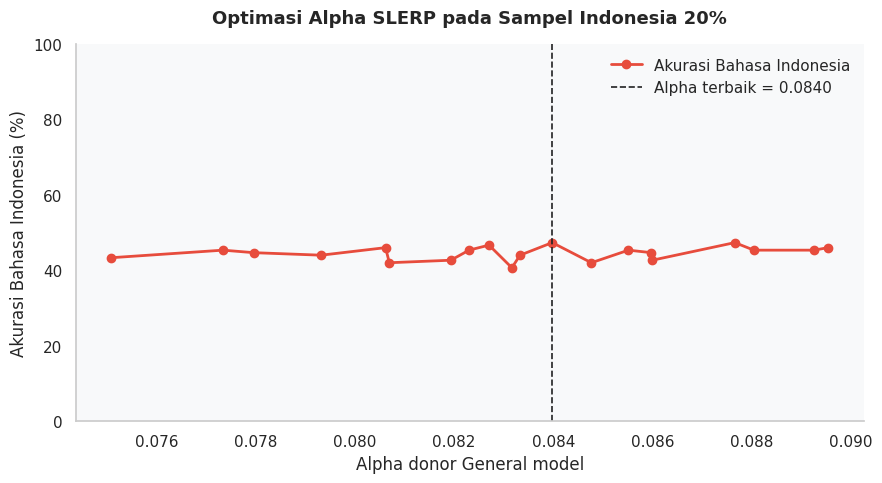

In [ ]:
def plot_alpha_optimization_curve(df_trials, best_alpha, id_color, charts_dir):
    """Membuat line chart hasil pencarian alpha SLERP terhadap akurasi Bahasa Indonesia.

    Fungsi ini memvisualisasikan hubungan antara nilai alpha (koefisien SLERP,
    proporsi kontribusi model General sebagai donor) dan akurasi yang dicapai
    pada sampel dataset Bahasa Indonesia selama pencarian Optuna, dengan garis
    vertikal putus-putus yang menandai alpha terbaik yang ditemukan.

    Args:
        df_trials: DataFrame hasil seluruh trial Optuna, wajib memiliki kolom
            "alpha" dan "accuracy_id" (skala desimal 0-1).
        best_alpha: Nilai alpha terbaik yang ditemukan oleh Optuna, digunakan
            untuk menggambar garis vertikal penanda pada chart.
        id_color: Kode warna (hex string) untuk garis kurva akurasi Bahasa
            Indonesia pada chart.
        charts_dir: Path direktori tempat chart akan disimpan sebagai PNG.

    Returns:
        None. Chart ditampilkan langsung dan disimpan ke charts_dir sebagai
        efek samping (side effect).
    """
    # Menerapkan tema visual seaborn dengan gaya minimalis: latar area plot
    # abu-abu sangat terang, latar figure putih, garis batas atas dan kanan
    # disembunyikan, dan grid dimatikan agar fokus visual sepenuhnya pada
    # kurva data itu sendiri.
    sns.set_theme(
        style="whitegrid",
        rc={
            "axes.facecolor": "#F8F9FA",
            "figure.facecolor": "#FFFFFF",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": False,
        },
    )

    # Mengurutkan data trial berdasarkan nilai alpha (bukan urutan trial asli)
    # agar garis kurva tergambar mulus dari alpha terkecil ke terbesar, tanpa
    # zig-zag akibat urutan eksekusi trial yang acak/non-monoton.
    df_trials_chart = df_trials.sort_values("alpha")

    fig, ax = plt.subplots(figsize=(9, 5))

    # Menggambar kurva akurasi Bahasa Indonesia terhadap alpha, dengan marker
    # bulat pada setiap titik trial agar terlihat jelas nilai diskrit yang
    # benar-benar dicoba oleh Optuna (bukan interpolasi kontinu).
    ax.plot(
        df_trials_chart["alpha"],
        df_trials_chart["accuracy_id"] * 100,
        marker="o",
        color=id_color,
        linewidth=2,
        label="Akurasi Bahasa Indonesia",
    )

    # Menggambar garis vertikal putus-putus pada posisi alpha terbaik yang
    # ditemukan Optuna, sebagai penanda visual langsung tanpa perlu mencari
    # titik tertinggi pada kurva secara manual.
    ax.axvline(
        best_alpha,
        color="#222222",
        linestyle="--",
        linewidth=1.2,
        label=f"Alpha terbaik = {best_alpha:.4f}",
    )

    ax.set_title(
        "Optimasi Alpha SLERP pada Sampel Indonesia 20%",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )

    ax.set_xlabel("Alpha donor General model")
    ax.set_ylabel("Akurasi Bahasa Indonesia (%)")
    ax.set_ylim(0, 100)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(charts_dir, "slerp_alpha_optimization_indonesian_20pct.png"),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# Memanggil fungsi menggunakan hasil trial Optuna (df_trials), alpha terbaik
# yang ditemukan (BEST_ALPHA), warna kurva (IDCOLOR), dan direktori
# penyimpanan chart (CHARTS_DIR) yang sudah didefinisikan sebelumnya.
plot_alpha_optimization_curve(
    df_trials=df_trials,
    best_alpha=BEST_ALPHA,
    id_color=IDCOLOR,
    charts_dir=CHARTS_DIR,
)

### Final Merge Menggunakan MergeKit CLI


In [ ]:
# Menetapkan nilai alpha terbaik yang ditemukan dari 20 trial pencarian Optuna
# sebelumnya (BEST_ALPHA = 0.083980), untuk digunakan pada proses merge final
# yang akan dievaluasi secara penuh (dataset lengkap, dua bahasa).
BEST_ALPHA = 0.083980
FINAL_MERGE_CONFIG_PATH = os.path.join(
    CONFIG_DIR,
    "final_slerp_mergekit.yaml",
)

# Membangun konfigurasi mergekit menggunakan fungsi yang sama persis dengan
# yang dipakai di setiap trial Optuna (build_mergekit_config), memastikan
# tidak ada celah perbedaan implementasi antara proses pencarian dan merge
# final, sesuai desain yang sudah dijelaskan di docstring fungsi tersebut.
final_mergekit_config = build_mergekit_config(BEST_ALPHA)

# Menyimpan konfigurasi merge final ke file YAML (bukan hanya dijalankan
# langsung dalam memori), agar konfigurasi ini bisa diarsipkan, diaudit, atau
# dijalankan ulang secara independen menggunakan CLI mergekit tanpa perlu
# menjalankan ulang seluruh notebook.
with open(
    FINAL_MERGE_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    yaml.dump(
        final_mergekit_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

# Menghapus direktori hasil merge final jika sudah ada dari eksekusi
# sebelumnya, mencegah percampuran file model lama dengan hasil merge baru,
# lalu membuat ulang direktori kosong agar siap menampung model hasil merge.
if os.path.exists(FINAL_MERGE_DIR):
    shutil.rmtree(FINAL_MERGE_DIR)

os.makedirs(FINAL_MERGE_DIR, exist_ok=True)

In [ ]:
run_merge(
    MergeConfiguration.model_validate(final_mergekit_config),
    out_path=FINAL_MERGE_DIR,
    options=MERGE_OPTIONS,
)

Warmup loader cache:   0%|          | 0/2 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Warmup loader cache:  50%|█████     | 1/2 [00:00<00:00,  1.32it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Executing graph: 100%|██████████| 1692/1692 [00:32<00:00, 52.46it/s]


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

### Check the chat template used by the merged model and by each individual model's tokenizer

In [ ]:
# Tokenizer & config dari kedua model sumber
# Memuat tokenizer asli dari kedua model sumber (math dan general) langsung
# dari Hugging Face Hub, sebagai baseline pembanding untuk memverifikasi
# tokenizer mana yang sebenarnya "menang" dan disalin ke model hasil merge.
tok_math = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B-Instruct")
tok_general = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# Tokenizer & config dari hasil merge (ganti path sesuai FINAL_MERGE_DIR kamu)
# Memuat tokenizer dari direktori hasil merge final, untuk dibandingkan
# terhadap kedua tokenizer sumber di atas.
tok_merged = AutoTokenizer.from_pretrained(FINAL_MERGE_DIR)

# 1. Bandingkan chat_template
# Memeriksa apakah chat_template (format prompt sistem-user-asisten) pada
# model hasil merge identik dengan salah satu model sumber, karena
# copy_tokenizer=True pada MERGE_OPTIONS seharusnya menyalin tokenizer dari
# base_model (MODEL_MATH) secara utuh tanpa modifikasi.
print("Math == Merged?   ", tok_math.chat_template == tok_merged.chat_template)
print("General == Merged?", tok_general.chat_template == tok_merged.chat_template)

# 2. Bandingkan special tokens penting
# Membandingkan token spesial krusial (eos_token untuk menandai akhir
# generasi, pad_token untuk padding batch) antar ketiga tokenizer, karena
# ketidakcocokan pada token ini bisa menyebabkan model hasil merge gagal
# berhenti generasi dengan benar atau salah menangani padding saat inference.
for name in ["eos_token", "eos_token_id", "pad_token", "pad_token_id"]:
    print(name, "| Math:", getattr(tok_math, name), "| General:", getattr(tok_general, name), "| Merged:", getattr(tok_merged, name))

# 3. Bandingkan generation_config model
# Memuat objek konfigurasi model (bukan tokenizer) dari model math sumber dan
# hasil merge, untuk memeriksa apakah eos_token_id pada level konfigurasi
# model (bukan hanya tokenizer) juga konsisten, karena beberapa pipeline
# generasi membaca eos_token_id dari config model, bukan dari tokenizer.
cfg_math = AutoConfig.from_pretrained("Qwen/Qwen2.5-Math-1.5B-Instruct")
cfg_merged = AutoConfig.from_pretrained(FINAL_MERGE_DIR)
print("eos_token_id (config) Math:", cfg_math.eos_token_id, "| Merged:", cfg_merged.eos_token_id)

Math == Merged?    True
General == Merged? False
eos_token | Math: <|im_end|> | General: <|im_end|> | Merged: <|im_end|>
eos_token_id | Math: 151645 | General: 151645 | Merged: 151645
pad_token | Math: <|endoftext|> | General: <|endoftext|> | Merged: <|endoftext|>
pad_token_id | Math: 151643 | General: 151643 | Merged: 151643
eos_token_id (config) Math: 151645 | Merged: 151645


## Section 7 - Final Evaluation: SLERP-Merged Model

 ### Indonesian Test Set (ID-CoT)

In [ ]:
BEST_ALPHA = 0.083980

In [ ]:
FINAL_MODEL_LABEL = (
    "SLERP-Qwen2.5-Math-General-1.5B-"
    f"alpha-{BEST_ALPHA:.4f}"
)

final_model, final_tokenizer = load_model_for_inference(
    FINAL_MERGE_DIR
)

==((====))==  Unsloth 2026.8.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [ ]:
raw_id_final = run_inference(
    model=final_model,
    tokenizer=final_tokenizer,
    questions=df_test["translated_question"],
    system_prompt=SYSTEM_PROMPT_ID,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="Final SLERP | Bahasa Indonesia",
)

Final SLERP | Bahasa Indonesia:   0%|          | 0/83 [00:00<?, ?it/s]

In [ ]:
result_id_final = evaluate_and_save(
    questions=df_test["translated_question"],
    raw_outputs=raw_id_final,
    ground_truths=df_test["answer"],
    strata_list=df_test["stratum"],
    output_prefix=os.path.join(
        EVAL_DIR,
        "final_slerp_indonesian_id_cot",
    ),
    language="Bahasa Indonesia",
    model_name=FINAL_MODEL_LABEL,
    prompt_name="ID-CoT",
)


Model        : SLERP-Qwen2.5-Math-General-1.5B-alpha-0.0840
Bahasa         : Bahasa Indonesia
Prompt         : ID-CoT
Akurasi        : 45.49%
Akurasi strata :
  L1: 53.95%
  L2: 37.50%
  L3: 31.33%
Metode ekstraksi jawaban (%):
{'boxed': 95.38, 'last_number_fallback': 3.94, 'not_found': 0.68}


### English Test Set (EN-CoT)

In [ ]:
raw_en_final = run_inference(
    model=final_model,
    tokenizer=final_tokenizer,
    questions=df_test["question"],
    system_prompt=SYSTEM_PROMPT_EN,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="Final SLERP | English",
)

Final SLERP | English:   0%|          | 0/83 [00:00<?, ?it/s]

In [ ]:
result_en_final = evaluate_and_save(
    questions=df_test["question"],
    raw_outputs=raw_en_final,
    ground_truths=df_test["answer"],
    strata_list=df_test["stratum"],
    output_prefix=os.path.join(
        EVAL_DIR,
        "final_slerp_english_en_cot",
    ),
    language="Bahasa Inggris",
    model_name=FINAL_MODEL_LABEL,
    prompt_name="EN-CoT",
)


Model        : SLERP-Qwen2.5-Math-General-1.5B-alpha-0.0840
Bahasa         : Bahasa Inggris
Prompt         : EN-CoT
Akurasi        : 84.69%
Akurasi strata :
  L1: 88.95%
  L2: 82.20%
  L3: 72.67%
Metode ekstraksi jawaban (%):
{'boxed': 99.55, 'last_number_fallback': 0.45}


In [ ]:
clear_vram(final_model, final_tokenizer)

## Section 8 - Chart Hasil SLERP: English vs Indonesia

In [ ]:
def plot_final_slerp_overall(result_en, result_id, best_alpha):
    """Membuat bar chart perbandingan akurasi akhir model hasil SLERP merge pada dua bahasa.

    Fungsi ini memvisualisasikan hasil evaluasi penuh (dataset lengkap, bukan
    sampel) dari model hasil SLERP merge final, menampilkan akurasi Bahasa
    Inggris (task asli/original) dan Bahasa Indonesia (task target) sebagai
    dua bar tunggal berdampingan, dengan nilai alpha final ditampilkan sebagai
    subjudul untuk konteks konfigurasi model yang dievaluasi.

    Args:
        result_en: Dictionary hasil evaluate_and_save untuk model merge pada
            Bahasa Inggris, wajib memiliki key "accuracy" (skala desimal 0-1).
        result_id: Dictionary hasil evaluate_and_save untuk model merge pada
            Bahasa Indonesia, wajib memiliki key "accuracy" (skala desimal 0-1).
        best_alpha: Nilai alpha SLERP yang digunakan pada model merge final,
            ditampilkan sebagai subjudul chart.

    Returns:
        DataFrame dengan kolom "Bahasa" dan "Akurasi", berisi dua baris
        (Bahasa Inggris dan Bahasa Indonesia) yang merepresentasikan data
        yang divisualisasikan pada chart.
    """
    labels = [
        "Bahasa Inggris\n(Original Task)",
        "Bahasa Indonesia\n(Target Task)"
    ]

    acc_en = result_en["accuracy"] * 100
    acc_id = result_id["accuracy"] * 100
    scores = [acc_en, acc_id]

    # Menyimpan data yang divisualisasikan sebagai DataFrame terpisah, agar
    # bisa dipakai untuk tabel lampiran skripsi atau analisis lanjutan tanpa
    # perlu mengekstrak ulang dari objek result_en/result_id.
    df_chart = pd.DataFrame({
        "Bahasa": labels,
        "Akurasi": scores
    })

    # Palet warna baku identik dengan chart lain di notebook ini: oranye
    # terang untuk Bahasa Inggris, oranye gelap untuk Bahasa Indonesia.
    colors = ['#f2c79e', '#d2691e']
    text_color = '#777777'
    title_color = '#666666'

    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')

    # Menggambar dua bar tunggal (bukan grouped bar seperti chart sebelumnya)
    # karena di sini hanya ada satu model (hasil merge) yang dibandingkan
    # antar dua bahasa, tanpa perlu offset kiri-kanan.
    width = 0.45
    rects = ax.bar(labels, scores, width=width, color=colors)

    # Menyembunyikan garis batas atas dan kanan, memberi warna gelap pada
    # garis batas kiri dan bawah, konsisten dengan gaya chart lain di notebook.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel('Akurasi (%)', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='y', colors=text_color)

    # Tidak ada set_xlabel karena label bar sendiri ("Bahasa Inggris",
    # "Bahasa Indonesia") sudah cukup menjelaskan tanpa perlu label sumbu tambahan.
    ax.tick_params(axis='x', colors=text_color, labelsize=11)

    # Menambahkan label nilai persentase di atas setiap bar, menggunakan
    # presisi dua desimal (.2f) agar konsisten dengan presisi yang dihasilkan
    # oleh evaluate_and_save.
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, color='black')

    # Menampilkan judul utama dan subjudul berupa nilai alpha final, sebagai
    # konteks konfigurasi SLERP yang dipakai pada model yang dievaluasi ini.
    fig.text(0.5, 0.94, 'Evaluasi Final Model Gabungan SLERP', ha='center', va='center',
             fontsize=17, fontweight='bold', color=title_color)
    fig.text(0.5, 0.88, f'Alpha = {best_alpha:.4f}', ha='center', va='center',
             fontsize=12, color=text_color)

    plt.tight_layout()
    # Margin atas disesuaikan ke 0.82 (berbeda dari chart lain yang pakai 0.78)
    # karena chart ini tidak memiliki legend, sehingga ruang atas yang
    # dibutuhkan untuk judul dan subjudul sedikit lebih kecil.
    plt.subplots_adjust(top=0.82)

    # Mencoba menyimpan chart ke CHARTS_DIR; jika variabel tersebut belum
    # didefinisikan (NameError), penyimpanan dilewati dengan pesan info tanpa
    # menghentikan eksekusi fungsi.
    try:
        save_path = os.path.join(CHARTS_DIR, "final_slerp_overall_comparison.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    except NameError:
        print(f"Info: Gambar belum disimpan karena CHARTS_DIR tidak ditemukan.")

    plt.show()

    return df_chart

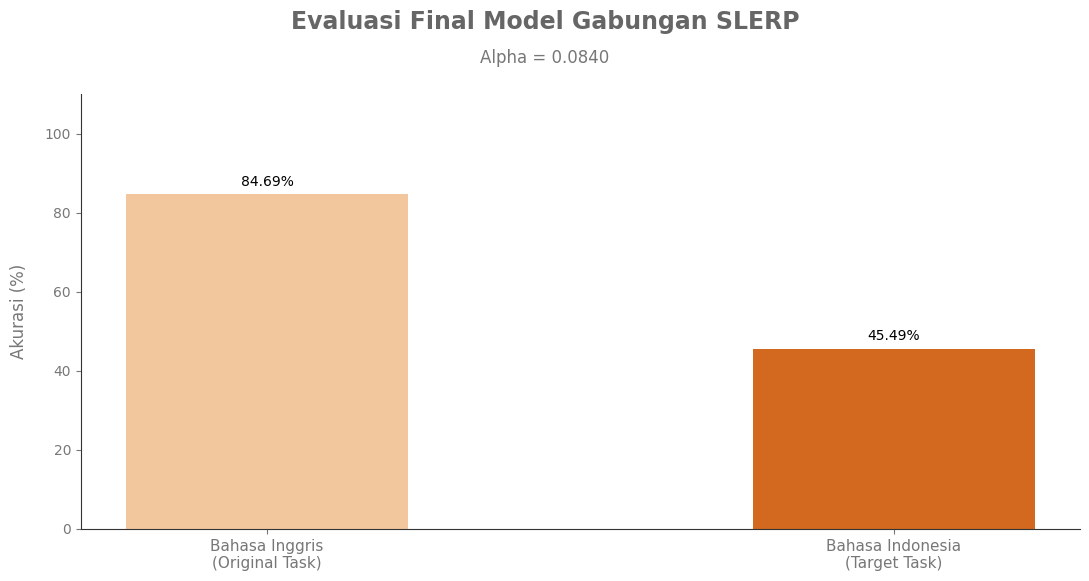

In [ ]:
df_chart_overall = plot_final_slerp_overall(
    result_en=result_en_final,
    result_id=result_id_final,
    best_alpha=BEST_ALPHA,
)

### Chart: Final SLERP Model Results by Complexity Stratum

In [ ]:
def plot_final_slerp_per_stratum(result_en, result_id):
    """Membuat grouped bar chart akurasi per stratum untuk model hasil SLERP merge final.

    Fungsi ini identik secara struktural dengan plot_stratum_comparison, namun
    dikhususkan untuk menampilkan hasil evaluasi model merge final (bukan model
    baseline general/math), dengan subjudul tetap "Model Gabungan SLERP".
    Menampilkan akurasi Bahasa Inggris dan Bahasa Indonesia berdampingan untuk
    setiap stratum/tingkat kesulitan pada STRATA.

    Args:
        result_en: Dictionary hasil evaluate_and_save untuk model merge pada
            Bahasa Inggris, wajib memiliki key "per_stratum" (dict stratum ->
            akurasi skala desimal 0-1).
        result_id: Dictionary hasil evaluate_and_save untuk model merge pada
            Bahasa Indonesia, wajib memiliki key "per_stratum".

    Returns:
        DataFrame long-format dengan kolom "Strata", "Bahasa", dan "Akurasi",
        berisi dua baris per stratum (Bahasa Inggris dan Bahasa Indonesia).
    """
    labels = []
    inggris_scores = []
    indonesia_scores = []
    chart_records = []

    # Mengiterasi STRATA (bukan langsung key dari result) agar urutan stratum
    # pada chart selalu konsisten sesuai definisi global.
    for stratum in STRATA:
        acc_en = result_en["per_stratum"][stratum] * 100
        acc_id = result_id["per_stratum"][stratum] * 100

        labels.append(stratum)
        inggris_scores.append(acc_en)
        indonesia_scores.append(acc_id)

        chart_records.append({
            "Strata": stratum,
            "Bahasa": "Bahasa Inggris",
            "Akurasi": acc_en
        })
        chart_records.append({
            "Strata": stratum,
            "Bahasa": "Bahasa Indonesia",
            "Akurasi": acc_id
        })

    # Posisi dasar tiap kelompok bar pada sumbu x, satu posisi per stratum.
    x = np.arange(len(labels))

    # Lebar bar dan offset dari posisi tengah, identik dengan konvensi layout
    # pada seluruh grouped bar chart di notebook ini.
    width = 0.34
    offset = 0.19

    # Palet warna baku, identik dengan chart-chart sebelumnya.
    color_en = '#f2c79e'
    color_id = '#d2691e'
    text_color = '#777777'
    title_color = '#666666'

    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')

    # Menggambar dua set bar bersebelahan: Bahasa Inggris di kiri, Bahasa
    # Indonesia di kanan, relatif terhadap posisi tengah tiap stratum.
    rects1 = ax.bar(x - offset, inggris_scores, width, label='Bahasa Inggris', color=color_en)
    rects2 = ax.bar(x + offset, indonesia_scores, width, label='Bahasa Indonesia', color=color_id)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel('Akurasi (%)', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='y', colors=text_color)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel('Strata', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='x', colors=text_color)

    def autolabel(rects):
        """Menambahkan label nilai persentase di atas setiap bar pada chart.

        Args:
            rects: Koleksi objek bar (hasil ax.bar) yang akan diberi label.

        Returns:
            None.
        """
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, color='black')

    autolabel(rects1)
    autolabel(rects2)

    # Judul tetap "Akurasi per Strata" dengan subjudul tetap "Model Gabungan
    # SLERP" (berbeda dari plot_stratum_comparison yang subjudulnya dinamis
    # mengikuti parameter model_name), karena fungsi ini khusus untuk satu
    # model hasil merge final saja.
    fig.text(0.5, 0.96, 'Akurasi per Strata', ha='center', va='center',
             fontsize=17, fontweight='bold', color=title_color)
    fig.text(0.5, 0.90, 'Model Gabungan SLERP', ha='center', va='center',
             fontsize=12, color=text_color)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False,
              handlelength=1, handleheight=1, labelcolor=text_color, fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(top=0.78)

    try:
        save_path = os.path.join(CHARTS_DIR, "final_slerp_per_stratum.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    except NameError:
        print(f"Info: Gambar belum disimpan karena CHARTS_DIR tidak ditemukan.")

    plt.show()

    return pd.DataFrame(chart_records)

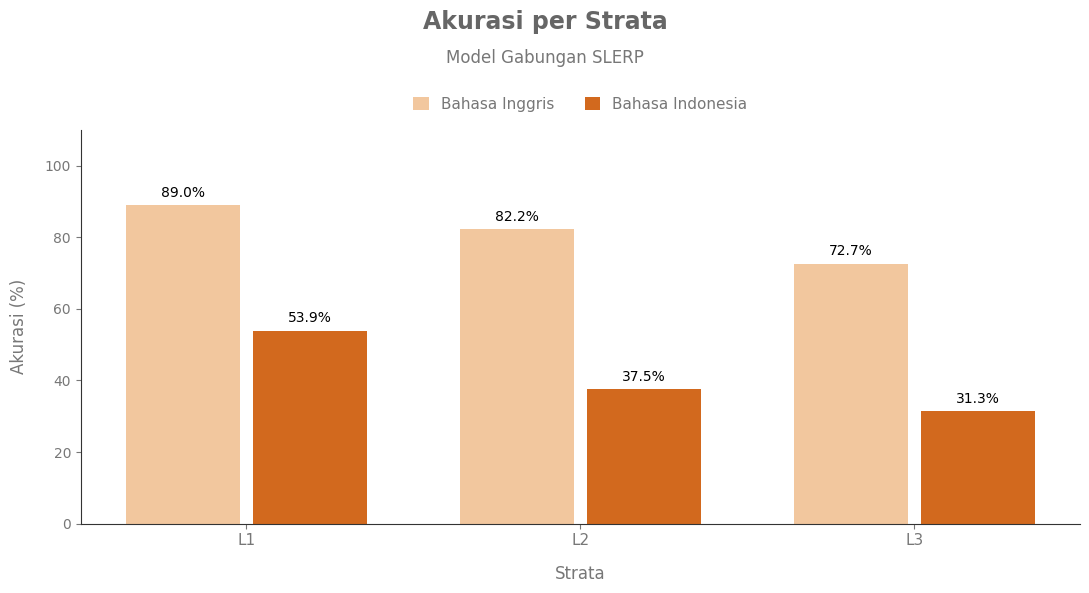

In [ ]:
df_chart_strata = plot_final_slerp_per_stratum(
    result_en=result_en_final,
    result_id=result_id_final,
)

## Section 9 - Analisis Jarak Parameter (Weight Similarity)

In [ ]:
def extract_tensor_info(tensor_name: str) -> dict:
    """Mengklasifikasikan nama tensor bobot model ke dalam kategori komponen dan posisi layer.

    Fungsi ini menguraikan nama parameter (state_dict key) dari arsitektur
    Transformer untuk menentukan komponen apa yang direpresentasikan (embedding,
    self-attention, MLP, LM head, atau final norm) beserta indeks layer-nya,
    berguna untuk analisis lebih lanjut seperti representational similarity
    atau visualisasi perbedaan bobot antar-layer pada model hasil SLERP merge.

    Args:
        tensor_name: Nama tensor/parameter mentah dari state_dict model
            (misal "model.layers.5.self_attn.q_proj.weight").

    Returns:
        Dictionary dengan tiga key:
        - layer_idx: int indeks layer, atau None untuk Embedding/LM Head/Final Norm.
        - component: salah satu dari "Embedding", "Self-Attention", "MLP",
          "LM Head", "Final Norm", atau "Other".
        - position: "start" untuk Embedding, "end" untuk LM Head/Final Norm,
          atau int(layer_idx) untuk komponen di dalam layer bernomor.
    """
    name = tensor_name.lower()

    if "lm_head" in name:
        return {"layer_idx": None, "component": "LM Head", "position": "end"}
    if "embed_tokens" in name:
        return {"layer_idx": None, "component": "Embedding", "position": "start"}
    if "norm.weight" in name and "layers" not in name:
        return {"layer_idx": None, "component": "Final Norm", "position": "end"}

    # Pattern: layers\.(\d+)\. mencocokkan literal "layers." diikuti satu atau
    # lebih digit yang ditangkap sebagai grup (indeks layer), lalu diikuti
    # literal "." lagi — misalnya mencocokkan "layers.5." pada nama tensor
    # "model.layers.5.self_attn.q_proj.weight" dan menangkap "5" sebagai grup 1.
    match = re.search(r"layers\.(\d+)\.", name)
    # Mengambil grup pertama (indeks layer) dan mengonversinya ke int jika
    # pattern ditemukan; None jika tensor bukan bagian dari layer bernomor
    # (misal Embedding, LM Head, atau Final Norm yang sudah ditangani di atas).
    layer_idx = int(match.group(1)) if match else None

    if "self_attn" in name:
        component = "Self-Attention"
    elif "mlp" in name:
        component = "MLP"
    else:
        component = "Other"

    return {"layer_idx": layer_idx, "component": component, "position": layer_idx}

In [ ]:

def load_model_state_dict(model_name_or_path: str, dtype=torch.bfloat16) -> dict:
    """Memuat model penuh dan mengembalikan copy independen dari state_dict-nya di CPU.

    Load model penuh (full size, bukan quantized) via AutoModelForCausalLM,
    lalu kembalikan state_dict-nya (di-copy ke CPU agar aman dari cleanup GPU).
    Fungsi ini secara eksplisit memindahkan setiap tensor ke CPU dan melepas
    referensi ke objek model sebelum membersihkan memori, sehingga tensor yang
    dikembalikan benar-benar independen dan tidak lagi terikat pada VRAM model
    aslinya (mengatasi risiko yang sebelumnya ditemukan pada state_dict_math/
    state_dict_general, yang masih menahan referensi ke storage model asli).

    Args:
        model_name_or_path: ID model Hugging Face Hub atau path lokal ke
            checkpoint model yang akan dimuat.
        dtype: Tipe data floating point untuk memuat model. Default torch.bfloat16.

    Returns:
        Dictionary berisi nama parameter dan tensor bobotnya, masing-masing
        sudah di-detach dari graph komputasi dan dipindahkan ke CPU.
    """
    print(f"Loading model: {model_name_or_path}")
    # Memuat model langsung ke GPU (device_map="cuda") dengan precision sesuai
    # parameter dtype, dan low_cpu_mem_usage=True untuk menghindari duplikasi
    # bobot sementara di RAM CPU selama proses loading berlangsung.
    model = AutoModelForCausalLM.from_pretrained(
        model_name_or_path,
        torch_dtype=dtype,
        low_cpu_mem_usage=True,
        device_map="cuda"
    )
    # Mengekstrak setiap tensor dari state_dict, memutus koneksinya dari graph
    # komputasi (detach) dan memindahkannya ke CPU. Langkah ini membuat tensor
    # hasil menjadi copy yang independen dari VRAM model asli, sehingga model
    # GPU-nya benar-benar bisa dibebaskan tanpa mempengaruhi state_dict yang
    # dikembalikan.
    state_dict = {k: v.detach().to("cpu") for k, v in model.state_dict().items()}

    # Bersihkan model dari GPU memory setelah state_dict diambil
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return state_dict

In [ ]:
def analyze_weight_similarity(anchor_path: str, merged_path: str, output_dir: str) -> pd.DataFrame:
    """Menganalisis cosine similarity antar tensor bobot dari model anchor dan model hasil merge.

    Fungsi ini memuat dua model (anchor dan hasil merge SLERP), menghitung
    cosine similarity antara setiap pasangan tensor bobot yang berpadanan
    (berdasarkan nama parameter yang sama), mengelompokkan hasilnya menggunakan
    extract_tensor_info (layer_idx, component, position), dan menyimpan hasil
    mentah maupun hasil agregasi ke CSV. Metrik ini membantu memahami seberapa
    besar perubahan representasi tiap komponen/layer akibat proses SLERP
    merging dibanding model anchor aslinya.

    Args:
        anchor_path: ID model Hugging Face Hub atau path lokal ke model anchor
            (biasanya model dasar sebelum merge, misal MODEL_MATH).
        merged_path: Path lokal ke model hasil SLERP merge yang akan dibandingkan.
        output_dir: Direktori untuk menyimpan file CSV hasil analisis (mentah
            dan hasil agregasi per layer/komponen).

    Returns:
        DataFrame hasil agregasi rata-rata cosine similarity per kombinasi
        layer_idx, component, dan position (tidak termasuk komponen "Final Norm").
    """
    os.makedirs(output_dir, exist_ok=True)

    print(f"Loading anchor: {anchor_path}")
    anchor_model = AutoModelForCausalLM.from_pretrained(
        anchor_path, torch_dtype=torch.bfloat16, low_cpu_mem_usage=True, device_map="cuda"
    )
    anchor_dict = anchor_model.state_dict()

    print(f"Loading merged: {merged_path}")
    merged_model = AutoModelForCausalLM.from_pretrained(
        merged_path, torch_dtype=torch.bfloat16, low_cpu_mem_usage=True, device_map="cuda"
    )
    merged_dict = merged_model.state_dict()

    # Membandingkan set nama parameter kedua model; jika tidak identik (misal
    # karena versi arsitektur berbeda), tetap lanjutkan analisis hanya pada
    # key yang cocok di kedua model, sambil memberi peringatan eksplisit
    # berapa banyak key yang terpaksa diabaikan.
    keys_anchor, keys_merged = set(anchor_dict.keys()), set(merged_dict.keys())
    common_keys = sorted(keys_anchor & keys_merged)
    if keys_anchor != keys_merged:
        print(f"[WARNING] Arsitektur tidak 100% identik. "
              f"Hanya di anchor: {len(keys_anchor - keys_merged)}, "
              f"hanya di merged: {len(keys_merged - keys_anchor)}. "
              f"Melanjutkan dengan {len(common_keys)} key yang cocok.")

    records = []
    for key in tqdm(common_keys, desc="Menghitung Cosine Similarity"):
        # Meratakan (flatten) setiap tensor menjadi vektor 1-D dan mengonversi
        # ke float32 sebelum komputasi similarity, agar hasil perhitungan
        # tidak terpengaruh presisi rendah bfloat16 saat operasi matematis.
        w1 = anchor_dict[key].float().flatten()
        w2 = merged_dict[key].float().flatten()

        if w1.shape != w2.shape:
            print(f"[SKIP] Shape mismatch di {key}: {tuple(w1.shape)} vs {tuple(w2.shape)}")
            continue

        # Validasi nilai tak-hingga / NaN sebelum dihitung
        if not torch.isfinite(w1).all() or not torch.isfinite(w2).all():
            print(f"[SKIP] NaN/Inf terdeteksi di {key}, tensor dilewati")
            continue

        cos_sim = F.cosine_similarity(w1.unsqueeze(0), w2.unsqueeze(0)).item()

        # Sanity check keras: cosine similarity WAJIB di [-1, 1]
        if cos_sim > 1.0 + 1e-4 or cos_sim < -1.0 - 1e-4:
            print(f"[BUG DETECTED] {key} -> cos_sim={cos_sim:.6f}, shape={tuple(w1.shape)} "
                  f"— nilai di luar batas matematis, cek ulang tensor ini secara manual!")
        cos_sim = float(np.clip(cos_sim, -1.0, 1.0))  # clamp demi keamanan plotting

        # Mengambil metadata klasifikasi tensor (layer_idx, component, position)
        # menggunakan extract_tensor_info, lalu menggabungkannya dengan hasil
        # cosine similarity dan shape asli tensor ke dalam satu record.
        info = extract_tensor_info(key)
        records.append({"tensor_name": key, **info, "cosine_similarity": cos_sim,
                         "shape": str(list(w1.shape))})

    # Membersihkan kedua model dan state_dict-nya dari memori setelah seluruh
    # perhitungan similarity selesai, karena tensor besar ini tidak lagi
    # diperlukan setelah records terkumpul.
    del anchor_model, merged_model, anchor_dict, merged_dict
    clear_vram()

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(output_dir, "weight_similarity_raw.csv"), index=False)

    # Mengagregasi cosine similarity rata-rata per kombinasi layer_idx,
    # component, dan position, mengecualikan komponen "Final Norm" (biasanya
    # hanya satu tensor tunggal yang tidak representatif untuk analisis
    # per-layer). dropna=False memastikan grup dengan layer_idx None
    # (misal Embedding, LM Head) tetap disertakan dalam hasil agregasi.
    df_grouped = (
        df[df["component"] != "Final Norm"]
        .groupby(["layer_idx", "component", "position"], dropna=False)["cosine_similarity"]
        .mean()
        .reset_index()
    )
    df_grouped.to_csv(os.path.join(output_dir, "weight_similarity_grouped.csv"), index=False)
    min_sim = df["cosine_similarity"].min()
    max_sim = df["cosine_similarity"].max()
    print(f"Selesai. Range cosine similarity: {min_sim:.4f} - {max_sim:.4f}")

    return df_grouped


In [ ]:
def plot_weight_similarity(df_grouped_1: pd.DataFrame,
                            df_grouped_2: pd.DataFrame,
                            title_1: str = "Model Gabungan (SLERP) vs. Qwen2.5-Math-1.5B-Instruct",
                            title_2: str = "Model Gabungan (SLERP) vs. Qwen2.5-1.5B-Instruct",
                            save_path: str = None):
    """Membuat visualisasi 2x2 perbandingan cosine similarity bobot antar dua pasangan model.

    Baris atas  : Aggregate cosine similarity per layer (bar chart, termasuk Embedding & LM Head).
    Baris bawah : Breakdown Self-Attention vs MLP (line chart), Embedding (kiri) dan
                  LM Head (kanan) ditampilkan sebagai diamond.

    Fungsi ini menampilkan dua kolom perbandingan berdampingan (misal: model
    merge vs anchor Math di kolom kiri, model merge vs donor General di kolom
    kanan), masing-masing dengan dua baris: bar chart ringkasan per layer, dan
    line chart breakdown komponen (Self-Attention, MLP, Embedding, LM Head).
    Tujuannya memvisualisasikan seberapa besar setiap layer/komponen berubah
    akibat proses SLERP merge, relatif terhadap masing-masing model sumber.

    Args:
        df_grouped_1: DataFrame hasil analyze_weight_similarity untuk
            perbandingan pertama (ditampilkan di kolom kiri), wajib memiliki
            kolom "layer_idx", "component", dan "cosine_similarity".
        df_grouped_2: DataFrame hasil analyze_weight_similarity untuk
            perbandingan kedua (ditampilkan di kolom kanan).
        title_1: Judul subplot untuk kolom kiri. Default perbandingan dengan
            Qwen2.5-Math-1.5B-Instruct.
        title_2: Judul subplot untuk kolom kanan. Default perbandingan dengan
            Qwen2.5-1.5B-Instruct.
        save_path: Path file untuk menyimpan chart sebagai gambar. Jika None,
            chart hanya ditampilkan tanpa disimpan.

    Returns:
        None. Chart ditampilkan langsung dan disimpan ke save_path (jika
        diberikan) sebagai efek samping (side effect).
    """
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'

    # Membuat grid 2 baris x 2 kolom: baris atas untuk bar chart ringkasan,
    # baris bawah untuk line chart breakdown, dengan sumbu x yang dibagi
    # (sharex='col') antar baris atas-bawah pada kolom yang sama.
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex='col')

    def _prepare(df_grouped):
        """Menyusun data ringkasan per layer dan per komponen dari hasil similarity mentah.

        Fungsi pembantu ini mengubah df_grouped (hasil analyze_weight_similarity)
        menjadi struktur data siap-plot: nilai rata-rata cosine similarity per
        posisi (Embedding, tiap layer bernomor, LM Head) untuk bar chart, serta
        nilai terpisah per komponen (Self-Attention, MLP) untuk line chart.

        Args:
            df_grouped: DataFrame hasil agregasi cosine similarity, wajib
                memiliki kolom "layer_idx", "component", dan "cosine_similarity".

        Returns:
            Dictionary berisi x_labels, x_pos, n_layers, bar_values (array
            nilai untuk bar chart per posisi), attn_values dan mlp_values
            (array nilai per layer untuk line chart), serta emb_val dan
            lmhead_val (nilai tunggal Embedding dan LM Head).
        """
        # Menentukan jumlah layer dari nilai maksimum layer_idx yang valid
        # (mengecualikan NaN dari Embedding/LM Head yang layer_idx-nya None),
        # lalu menyusun label sumbu x: "E" (Embedding) di awal, nomor layer
        # di tengah, "LM Head" di akhir.
        n_layers = int(df_grouped.loc[df_grouped['layer_idx'].notna(), 'layer_idx'].max()) + 1
        x_labels = ['E'] + [str(i) for i in range(n_layers)] + ['LM Head']
        x_pos = np.arange(len(x_labels))

        # Menyiapkan array nilai bar chart sepanjang seluruh posisi (Embedding,
        # semua layer, LM Head), diawali dengan NaN agar posisi yang datanya
        # tidak tersedia otomatis tidak digambar oleh matplotlib.
        bar_values = np.full(len(x_labels), np.nan)
        emb_val = df_grouped.loc[df_grouped['component'] == 'Embedding', 'cosine_similarity']
        lmhead_val = df_grouped.loc[df_grouped['component'] == 'LM Head', 'cosine_similarity']
        emb_val = emb_val.mean() if len(emb_val) else np.nan
        lmhead_val = lmhead_val.mean() if len(lmhead_val) else np.nan
        bar_values[0], bar_values[-1] = emb_val, lmhead_val

        # Mengisi nilai Self-Attention dan MLP per layer secara terpisah
        # (untuk line chart breakdown), sekaligus mengisi bar_values pada
        # posisi layer bersangkutan dengan rata-rata gabungan Self-Attention
        # dan MLP (nanmean mengabaikan nilai yang hilang jika salah satu
        # komponen tidak tersedia pada layer tersebut).
        attn_values = np.full(n_layers, np.nan)
        mlp_values = np.full(n_layers, np.nan)
        for i in range(n_layers):
            a = df_grouped.loc[(df_grouped['layer_idx'] == i) & (df_grouped['component'] == 'Self-Attention'), 'cosine_similarity']
            m = df_grouped.loc[(df_grouped['layer_idx'] == i) & (df_grouped['component'] == 'MLP'), 'cosine_similarity']
            if len(a): attn_values[i] = a.mean()
            if len(m): mlp_values[i] = m.mean()
            if len(a) or len(m):
                bar_values[1 + i] = np.nanmean([attn_values[i], mlp_values[i]])

        return dict(x_labels=x_labels, x_pos=x_pos, n_layers=n_layers,
                    bar_values=bar_values, attn_values=attn_values, mlp_values=mlp_values,
                    emb_val=emb_val, lmhead_val=lmhead_val)

    d1, d2 = _prepare(df_grouped_1), _prepare(df_grouped_2)

    # Mengisi kedua kolom subplot (kiri untuk d1, kanan untuk d2) dengan bar
    # chart ringkasan (baris atas) dan line chart breakdown (baris bawah),
    # menggunakan palet warna berbeda per kolom agar kedua perbandingan
    # (vs Math dan vs General) tetap bisa dibedakan secara visual.
    for col, (d, title) in enumerate(zip([d1, d2], [title_1, title_2])):
        ax_bar, ax_line = axes[0, col], axes[1, col]
        bar_color = '#a0c4ff' if col == 0 else '#b0b0ff'
        bar_edge = '#4d79ff' if col == 0 else '#7070ff'

        ax_bar.bar(d['x_pos'], d['bar_values'], color=bar_color, edgecolor=bar_edge, linewidth=1)
        ax_bar.set_title(title, fontsize=10, pad=18)
        ax_bar.text(0.5, 1.02, "Cosine Similarity", fontsize=8, color='#555555',
                    ha='center', va='bottom', transform=ax_bar.transAxes)

        # Menggambar Embedding dan LM Head sebagai marker diamond tunggal di
        # posisi paling kiri dan kanan, sementara Self-Attention dan MLP
        # digambar sebagai garis dengan marker "+" di sepanjang layer tengah.
        # Label legend hanya diberikan sekali (col==1 untuk Embedding/LM Head,
        # col==0 untuk Self-Attention/MLP) untuk mencegah duplikasi entri
        # legend saat digabung nanti di fig.legend.
        layer_x = d['x_pos'][1:-1]
        ax_line.plot(d['x_pos'][0], d['emb_val'], marker='D', color='#5c6b73', linestyle='None',
                     label='Embedding' if col == 1 else None)
        ax_line.plot(d['x_pos'][-1], d['lmhead_val'], marker='D', color='#5c6b73', linestyle='None',
                     label='LM Head' if col == 1 else None)
        ax_line.plot(layer_x, d['attn_values'], marker='+', color='#e87a20',
                     label='Self-Attention' if col == 0 else None)
        ax_line.plot(layer_x, d['mlp_values'], marker='+', color='#4d4dff',
                     label='MLP' if col == 0 else None)

        # Menampilkan tick label hanya pada Embedding, tiap 2 layer, dan LM
        # Head (bukan seluruh layer) agar sumbu x tidak terlalu padat/tumpang
        # tindih, dengan rotasi label 45 derajat jika jumlah tick cukup banyak.
        tick_pos = [0] + list(range(2, d['n_layers'], 2)) + [len(d['x_labels']) - 1]
        tick_labels = ['E'] + [str(i) for i in range(2, d['n_layers'], 2)] + ['LM\nHead']
        ax_line.set_xticks(tick_pos)
        ax_line.set_xticklabels(tick_labels, rotation=45 if len(tick_labels) > 15 else 0)
        ax_line.set_xlabel('Layer', fontsize=11)

    # Menonaktifkan grid vertikal (sumbu x) pada seluruh subplot dan menebalkan
    # garis batas (spines) untuk tampilan yang lebih tegas, khas gaya publikasi
    # ilmiah/serif yang sudah diatur di plt.rcParams sebelumnya.
    for ax in axes.flat:
        ax.xaxis.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

    plt.subplots_adjust(wspace=0.25, hspace=0.2, bottom=0.22)

    # Mengumpulkan seluruh handle dan label legend dari kedua subplot baris
    # bawah, lalu menghapus duplikat (karena label yang sama sengaja diberi
    # None pada salah satu kolom sebelumnya, tapi tetap dijaga urutannya
    # menggunakan set "seen" untuk mencegah entri ganda pada legend gabungan).
    handles, labels = [], []
    for ax in [axes[1, 0], axes[1, 1]]:
        h, l = ax.get_legend_handles_labels()
        handles += h; labels += l
    seen, uh, ul = set(), [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            uh.append(h); ul.append(l); seen.add(l)

    # Menampilkan satu legend gabungan tunggal di bagian bawah figure (bukan
    # per subplot), mencakup keempat kategori (Embedding, Self-Attention, MLP,
    # LM Head) dalam satu baris horizontal.
    fig.legend(uh, ul, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02),
               frameon=True, edgecolor='lightgray')

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
output_dir = os.path.join(ROOT_OUTPUT_DIR, "weight_similarity")

In [ ]:
merged_state_dict = load_model_state_dict(FINAL_MERGE_DIR)

Loading model: /content/drive/MyDrive/Dataset Skripsi/Result Model Merging Dual Prompt Full Size/final_slerp_mergekit


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [ ]:
# Membandingkan cosine similarity bobot antara model anchor Math dan model
# hasil SLERP merge, lalu menyimpan hasil analisis ke subdirektori "vs_math".
# Fungsi analyze_weight_similarity telah menangani loading model, perhitungan,
# penyimpanan CSV, serta pembersihan model dan cache VRAM secara internal.
df_math = analyze_weight_similarity(
    MODEL_MATH,
    FINAL_MERGE_DIR,
    os.path.join(output_dir, "vs_math"),
)

Loading model: Qwen/Qwen2.5-Math-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading anchor: Qwen/Qwen2.5-Math-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading merged: /content/drive/MyDrive/Dataset Skripsi/Result Model Merging Dual Prompt Full Size/final_slerp_mergekit


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Menghitung Cosine Similarity:   0%|          | 0/339 [00:00<?, ?it/s]

Selesai. Range cosine similarity: 0.9382 – 1.0000


In [ ]:
# Membandingkan cosine similarity bobot antara model General dan model hasil
# SLERP merge, lalu menyimpan hasil analisis ke subdirektori "vs_base".
# Fungsi analyze_weight_similarity telah menangani pemuatan kedua model,
# perhitungan similarity, penyimpanan CSV, dan pembersihan memori internal.
df_base = analyze_weight_similarity(
    MODEL_GENERAL,
    FINAL_MERGE_DIR,
    os.path.join(output_dir, "vs_base"),
)

Loading model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading anchor: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading merged: /content/drive/MyDrive/Dataset Skripsi/Result Model Merging Dual Prompt Full Size/final_slerp_mergekit


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Menghitung Cosine Similarity:   0%|          | 0/339 [00:00<?, ?it/s]

Selesai. Range cosine similarity: 0.1616 – 0.9986


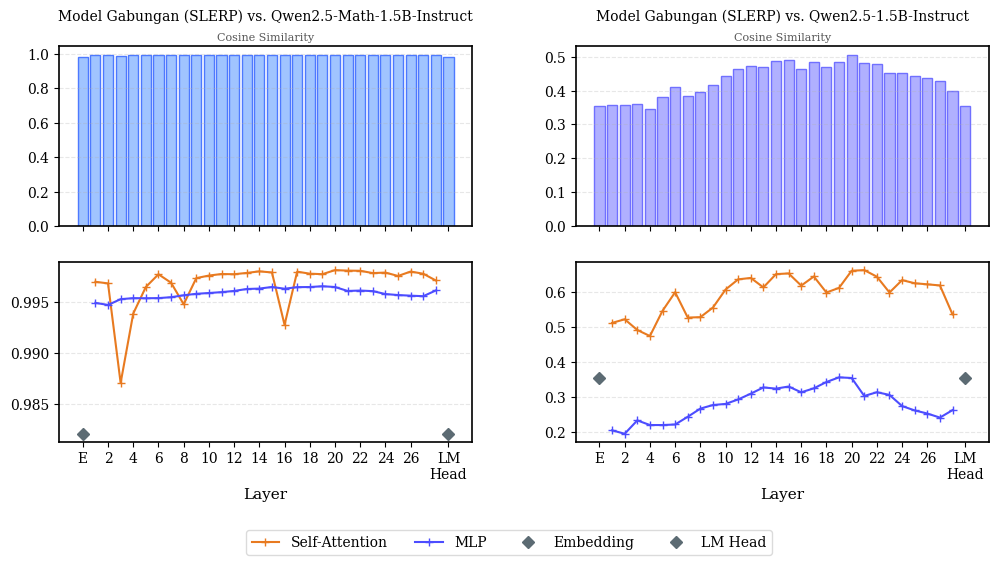

In [ ]:
plot_weight_similarity(
    df_math, df_base,
    title_1="Model Gabungan (SLERP) vs. Qwen2.5-Math-1.5B-Instruct",
    title_2="Model Gabungan (SLERP) vs. Qwen2.5-1.5B-Instruct",
    save_path=os.path.join(output_dir, "weight_similarity_plot.png")
)